# test-resample-paper.ipynb

Validation notebook for the J-STARS paper:

**healpix-resample: a PSF-Aware HEALPix Resampling for Earth Observation Imagery**

This notebook extends `test-resample_with_esri_sampler.ipynb` by adding **classical resampling baselines** (nearest-neighbor, bilinear, bicubic) for direct comparison with the PSF-aware method in:
- **Table I** – Synthetic detector experiment (HEALPix-domain metrics)
- **Table II** – Real Sentinel-2 round-trip metrics (UTM → HEALPix → UTM)


## 0. Installation notes

Run only if packages are missing.

In [1]:
# Optional installation cell
# %pip install -U numpy pandas scipy scikit-image matplotlib xarray zarr pyproj pystac-client xarray-eopf healpix-resample healpy foscat


## 1. Imports and configuration

In [2]:
from pathlib import Path
import os
import time
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import xarray as xr
import pyproj
import pystac_client

from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator, griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim
from skimage import exposure

try:
    from healpix_resample import PSFResampler
except Exception as exc:
    PSFResampler = None
    warnings.warn(f"Could not import PSFResampler: {exc}")

try:
    import healpy as hp
except Exception as exc:
    hp = None
    warnings.warn(f"Could not import healpy: {exc}")

try:
    from foscat.Plot import power_spectrum_1d, lgnomproject
except Exception as exc:
    power_spectrum_1d = None
    lgnomproject = None
    warnings.warn(f"Could not import foscat plotting utilities: {exc}")

DATA_DIR   = Path("data")
FIG_DIR    = Path("figures")
TABLE_DIR  = Path("tables")
for d in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(exist_ok=True)

RANDOM_SEED  = 1234
np.random.seed(RANDOM_SEED)

# ── Paper default parameters ─────────────────────────────────────────────────
HEALPIX_LEVEL = 20
PATCH_SIZE    = 256
CENTRAL_SIZE  = PATCH_SIZE
BAND          = "b04"      # Sentinel-2 red band
LAMBDA        = 0.0
MAX_ITER      = 14
THRESHOLD     = 0.1
FWHM          = 12.6       # metres

# Classical resampling methods to benchmark
CLASSICAL_METHODS = ["nearest", "linear", "cubic"]


# ── PSF-mismatch sensitivity test (paper Table I, extra columns) ────────────
# Operator PSF deliberately mis-specified relative to the true generation FWHM,
# to test robustness when the assumed spatial response does not exactly match
# reality (the FWHM/-50% case is expected to be more ill-conditioned; raise
# LAMBDA_PSF_AWARE_NARROW if the reconstruction looks noisy).
FWHM_PSF_AWARE_WIDE     = FWHM * 1.5
FWHM_PSF_AWARE_NARROW   = FWHM * 0.5
LAMBDA_PSF_AWARE_NARROW = 1E-3  # TODO: tune upward if noisy; LAMBDA (0.0) is used for the wide case
RICHARDSON_LUCY_ITER    = 100

try:
    from skimage.restoration import richardson_lucy
except Exception as exc:
    richardson_lucy = None
    warnings.warn(f"Could not import richardson_lucy: {exc}")


## 2. Benchmark scenes

In [3]:
benchmark_coordinates = {
    "urban": {
        "location": "Paris, France",
        "wgs84": {"lat": 48.8566, "lon": 2.3522},
        "recommended_date": "2025-05-01/2025-05-30",
        "cloud": 20,
    },
    "water": {
        "location": "Lake Geneva, Switzerland",
        "wgs84": {"lat": 46.4983, "lon": 6.6327},
        "recommended_date": "2025-06-01/2025-06-30",
        "cloud": 20,
    },
    "forest": {
        "location": "Black Forest, Germany",
        "wgs84": {"lat": 48.265, "lon": 8.016},
        "recommended_date": "2025-07-01/2025-07-31",
        "cloud": 20,
    },
    "agriculture": {
        "location": "Beauce plains, France",
        "wgs84": {"lat": 48.258, "lon": 1.499},
        "recommended_date": "2025-06-01/2025-06-30",
        "cloud": 20,
    },
}


## 3. Sentinel-2 extraction utilities

In [4]:
xr.set_options(keep_attrs=True, display_expand_attrs=False)
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

def _add_latlon(ds, transformer):
    xx, yy = np.meshgrid(ds.x.values, ds.y.values)
    lon, lat = transformer.transform(xx, yy)
    ds = ds.assign_coords(longitude=(["y", "x"], lon), latitude=(["y", "x"], lat))
    return ds

def extract_bench_data(scene, patch_size=PATCH_SIZE, force=False):
    path = DATA_DIR / f"{scene}_data.zarr"
    if path.exists() and not force:
        return
    coords = benchmark_coordinates[scene]
    lat0, lon0 = coords["wgs84"]["lat"], coords["wgs84"]["lon"]
    items = list(catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[lon0 - 0.05, lat0 - 0.05, lon0 + 0.05, lat0 + 0.05],
        datetime=coords["recommended_date"],
        query={"eo:cloud_cover": {"lt": coords["cloud"]}},
    ).get_all_items())
    if not items:
        raise RuntimeError(f"No items for {scene}")
    item = items[0]
    ds = xr.open_dataset(item.assets[BAND].href, engine="xarray-eopf", chunks={})
    transformer = pyproj.Transformer.from_crs(ds.crs_code, pyproj.CRS.from_epsg(4326), always_xy=True)
    x_c = float(ds.x.mean())
    y_c = float(ds.y.mean())
    half = patch_size // 2 * 10
    ds_patch = ds.sel(
        x=slice(x_c - half, x_c + half),
        y=slice(y_c + half, y_c - half),
    )
    ds_patch = _add_latlon(ds_patch, transformer)
    ds_patch.to_zarr(path, mode="w")


## 4. Download or load scenes

In [5]:
FORCE_DOWNLOAD = False
for scene in benchmark_coordinates:
    try:
        extract_bench_data(scene, force=FORCE_DOWNLOAD)
        print(f"[OK] {scene}")
    except Exception as exc:
        print(f"[WARN] {scene}: {exc}")


[OK] urban
[OK] water
[OK] forest
[OK] agriculture


## 5. Common utilities

In [6]:
def central_crop(img, size=CENTRAL_SIZE):
    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]

def fill_nan_with_mean(img):
    img = np.asarray(img, dtype=np.float32).copy()
    mask = np.isfinite(img)
    if not mask.any():
        raise ValueError("Image contains no finite pixels.")
    img[~mask] = np.nanmean(img)
    return img

def load_scene_patch(scene_name):
    path = DATA_DIR / f"{scene_name}_data.zarr"
    dt = xr.open_datatree(path, engine="zarr", consolidated=False, chunks={})
    da = dt[BAND]
    img = fill_nan_with_mean(da.values)
    lon = da["longitude"].values.astype(np.float64)
    lat = da["latitude"].values.astype(np.float64)
    return img, lon, lat, da

def normalize01(x):
    x = np.asarray(x, dtype=np.float64)
    p1, p99 = np.nanpercentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x)
    return np.clip((x - p1) / (p99 - p1), 0, 1)

def get_utm_axes(da, central_size=CENTRAL_SIZE):
    """Return 1-D UTM x and y axes for the central crop of a DataArray."""
    x_full = da.x.values
    y_full = da.y.values
    nx, ny = x_full.size, y_full.size
    cx, cy = nx // 2, ny // 2
    h = central_size // 2
    x0 = x_full[cx - h:cx + h]
    y0 = y_full[cy - h:cy + h]
    return x0, y0

def prepare_regular_interpolator(y_axis, x_axis, image, method="linear"):
    """RegularGridInterpolator handling potentially descending axes."""
    y = np.asarray(y_axis, dtype=np.float64)
    x = np.asarray(x_axis, dtype=np.float64)
    img = np.asarray(image, dtype=np.float64)
    if y[0] > y[-1]:
        y = y[::-1]; img = img[::-1, :]
    if x[0] > x[-1]:
        x = x[::-1]; img = img[:, ::-1]
    return RegularGridInterpolator((y, x), img, method=method,
                                   bounds_error=False, fill_value=np.nan)


## 6. Metrics

In [7]:
def compute_metrics(reference, reconstructed, name, method):
    ref = np.asarray(reference, dtype=np.float64)
    rec = np.asarray(reconstructed, dtype=np.float64)
    mask = np.isfinite(ref) & np.isfinite(rec)
    refv, recv = ref[mask], rec[mask]
    err = recv - refv

    rmse  = float(np.sqrt(mean_squared_error(refv, recv)))
    mae   = float(mean_absolute_error(refv, recv))
    bias  = float(np.mean(err))
    corr  = float(np.corrcoef(refv, recv)[0, 1]) if refv.size > 1 else np.nan
    r2    = float(r2_score(refv, recv))
    dr    = float(np.nanmax(ref) - np.nanmin(ref))
    psnr  = (float("inf") if rmse == 0
             else float(20 * np.log10(dr / rmse)) if dr > 0 else np.nan)
    # Fill any remaining NaN before SSIM (e.g. border pixels from griddata)
    ref_s = np.where(np.isfinite(ref), ref, np.nanmean(ref))
    rec_s = np.where(np.isfinite(rec), rec, np.nanmean(rec))
    ref01 = normalize01(ref_s); rec01 = normalize01(rec_s)
    ssim_val = float(ssim(ref01, rec01, data_range=1.0))

    return {"scene": name, "method": method,
            "rmse": rmse, "mae": mae, "bias": bias,
            "corr": corr, "r2": r2, "psnr_db": psnr, "ssim": ssim_val}

def scalar_metrics(ref, val, scene, method, comparison):
    ref = np.asarray(ref, dtype=np.float64)
    val = np.asarray(val, dtype=np.float64)
    mask = np.isfinite(ref) & np.isfinite(val)
    ref, val = ref[mask], val[mask]
    err = val - ref
    return {
        "scene": scene, "method": method, "comparison": comparison,
        "n":    int(ref.size),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mae":  float(np.mean(np.abs(err))),
        "bias": float(np.mean(err)),
        "corr": float(np.corrcoef(ref, val)[0, 1]) if ref.size > 2 else np.nan,
        "r2":   float(r2_score(ref, val)) if ref.size > 2 else np.nan,
    }


## 7. Power spectral density utilities

In [8]:
def prepare_for_psd(img, normalize=True, apodize=True):
    arr = np.asarray(img, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, np.nanmean(arr))
    if normalize:
        p1, p99 = np.nanpercentile(arr, [1, 99])
        if p99 > p1:
            arr = np.clip((arr - p1) / (p99 - p1), 0, 1)
    arr = arr - np.mean(arr)
    if apodize:
        wy = np.hanning(arr.shape[0])
        wx = np.hanning(arr.shape[1])
        arr = arr * np.outer(wy, wx)
    return arr

def psd1d_numpy(img):
    arr = prepare_for_psd(img)
    ft  = np.fft.fftshift(np.fft.fft2(arr))
    psd2 = np.abs(ft) ** 2
    ny, nx = arr.shape
    yy, xx = np.indices((ny, nx))
    rr = np.sqrt((xx - nx // 2) ** 2 + (yy - ny // 2) ** 2).astype(np.int64)
    max_r = min(nx, ny) // 2
    psd_sum   = np.bincount(rr.ravel(), weights=psd2.ravel(), minlength=max_r)
    psd_count = np.bincount(rr.ravel(), minlength=max_r)
    psd = psd_sum[:max_r] / np.maximum(psd_count[:max_r], 1)
    k   = np.arange(max_r)
    return k[1:], psd[1:]


## 8. PSF-aware resampler (proposed method)

In [9]:
def psf_resample_scene(
    scene_name,
    level=HEALPIX_LEVEL,
    lam=LAMBDA,
    max_iter=MAX_ITER,
    threshold=THRESHOLD,
    force=False,
):
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available. Install healpix-resample.")

    out_npz = DATA_DIR / f"{scene_name}_psf_resample_level{level}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon, lat, da = load_scene_patch(scene_name)
    img = central_crop(img); lon = central_crop(lon); lat = central_crop(lat)

    t0 = time.time()
    resampler = PSFResampler(
        lon_deg=lon.reshape(-1), lat_deg=lat.reshape(-1),
        level=level, threshold=threshold, verbose=True,
    )
    build_time = time.time() - t0

    t1 = time.time()
    res = resampler.resample(img.reshape(-1), lam=lam, max_iter=max_iter)
    inversion_time = time.time() - t1

    t2 = time.time()
    rec_flat = resampler.invert(res.cell_data)
    projection_time = time.time() - t2

    rec      = np.asarray(rec_flat).reshape(img.shape)
    residual = rec - img

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level,
        original=img.astype(np.float32),
        reconstructed=rec.astype(np.float32),
        residual=residual.astype(np.float32),
        cell_ids=np.asarray(res.cell_ids),
        cell_data=np.asarray(res.cell_data, dtype=np.float32),
        build_time=build_time,
        inversion_time=inversion_time,
        projection_time=projection_time,
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 9. Classical resampling baselines

Each method performs a two-step round-trip:
1. **UTM → HEALPix**: sample the UTM raster at HEALPix cell centres using the selected interpolation order.
2. **HEALPix → UTM**: scatter HEALPix values back to the original UTM grid using `scipy.interpolate.griddata`.

Methods benchmarked: `nearest` (nearest-neighbour), `linear` (bilinear), `cubic` (bicubic).


In [10]:
def classical_resample_scene(
    scene_name,
    method="linear",
    level=HEALPIX_LEVEL,
    force=False,
):
    """
    Classical UTM → HEALPix → UTM round-trip using geometric interpolation.

    Parameters
    ----------
    method : str
        One of 'nearest', 'linear', 'cubic'.
        Controls both the forward (UTM→HEALPix) and inverse (HEALPix→UTM) steps.
    """
    if hp is None:
        raise ImportError("healpy is required for classical_resample_scene.")

    out_npz = DATA_DIR / f"{scene_name}_classical_{method}_level{level}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon, lat, da = load_scene_patch(scene_name)
    img = central_crop(img)
    lon = central_crop(lon)
    lat = central_crop(lat)

    x0, y0 = get_utm_axes(da)
    ny, nx  = img.shape

    # ── Step 1: find HEALPix cells that cover the patch ──────────────────────
    nside    = 2 ** level
    pix_ids  = hp.ang2pix(nside, lon.ravel(), lat.ravel(), lonlat=True, nest=True)
    cell_ids = np.unique(pix_ids)

    hpx_lon, hpx_lat = hp.pix2ang(nside, cell_ids, lonlat=True, nest=True)

    # Convert HEALPix cell centres to UTM
    crs_utm = da.crs_code
    t_fwd   = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    # ── Step 2: UTM → HEALPix (forward, geometric interpolation) ─────────────
    # Use RegularGridInterpolator on the regular UTM grid.
    # 'cubic' is not supported by RGI in all scipy versions; fall back to griddata.
    utm_points = np.column_stack([lon.ravel(), lat.ravel()])

    if method in ("nearest", "linear"):
        rgi_method = method
        interp_fwd = prepare_regular_interpolator(y0, x0, img, method=rgi_method)
        hpx_values = interp_fwd(np.column_stack([hpx_y, hpx_x]))
    else:
        # cubic: use griddata on the regular UTM grid points expressed in (x, y)
        xx_utm, yy_utm = np.meshgrid(x0, y0)
        hpx_values = griddata(
            points=np.column_stack([xx_utm.ravel(), yy_utm.ravel()]),
            values=img.ravel(),
            xi=np.column_stack([hpx_x, hpx_y]),
            method=method,
        )

    # Fill any NaN HEALPix values with nearest-neighbour
    if np.any(~np.isfinite(hpx_values)):
        interp_nn = prepare_regular_interpolator(y0, x0, img, method="nearest")
        hpx_nn    = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    # ── Step 3: HEALPix → UTM (inverse, geometric interpolation) ─────────────
    xx_utm, yy_utm = np.meshgrid(x0, y0)
    query_pts = np.column_stack([hpx_x, hpx_y])
    target_pts = np.column_stack([xx_utm.ravel(), yy_utm.ravel()])

    rec = griddata(
        points=query_pts,
        values=hpx_values,
        xi=target_pts,
        method=method,
    ).reshape(ny, nx)

    # Fill border NaNs with nearest-neighbour
    if np.any(~np.isfinite(rec)):
        rec_nn = griddata(
            points=query_pts,
            values=hpx_values,
            xi=target_pts,
            method="nearest",
        ).reshape(ny, nx)
        rec = np.where(np.isfinite(rec), rec, rec_nn)

    residual = rec.astype(np.float32) - img.astype(np.float32)
    t_total  = 0.0  # no meaningful timer for this path

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, method=method,
        original=img.astype(np.float32),
        reconstructed=rec.astype(np.float32),
        residual=residual,
        cell_ids=cell_ids.astype(np.int64),
        cell_data=hpx_values.astype(np.float32),
        total_time=t_total,
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 10. Round-trip experiment — all methods

In [11]:
def run_all_roundtrip(force=False):
    """Run PSF-aware + all classical methods on all scenes. Return metrics DataFrame."""
    rows = []

    for scene in benchmark_coordinates:
        # ── PSF-aware ────────────────────────────────────────────────────────
        try:
            psf = psf_resample_scene(scene, force=force)
            rows.append(compute_metrics(psf["original"], psf["reconstructed"], scene, "psf_aware"))
        except Exception as exc:
            print(f"[WARN] PSF-aware failed for {scene}: {exc}")

        # ── Classical baselines ──────────────────────────────────────────────
        for method in CLASSICAL_METHODS:
            try:
                cl = classical_resample_scene(scene, method=method, force=force)
                rows.append(compute_metrics(cl["original"], cl["reconstructed"], scene, f"classical_{method}"))
            except Exception as exc:
                print(f"[WARN] Classical {method} failed for {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "roundtrip_metrics_all_methods.csv", index=False)
    return df

df_roundtrip = run_all_roundtrip(force=False)
df_roundtrip


,scene,method,rmse,mae,bias,corr,r2,psnr_db,ssim
0,urban,psf_aware,1.626924e-08,1.064653e-08,-3.727152e-11,1.000000,1.000000,160.376524,1.000000
1,urban,classical_nearest,5.675114e-03,1.075811e-04,2.190504e-05,0.995507,0.990932,49.524376,0.997038
2,urban,classical_linear,1.164100e-02,6.823043e-03,-2.724049e-05,0.983714,0.961846,43.284059,0.956522
3,urban,classical_cubic,1.183400e-02,6.341552e-03,-2.557270e-05,0.980109,0.960570,43.141235,0.962474
4,water,psf_aware,6.817999e-09,2.486252e-09,1.355581e-11,1.000000,1.000000,161.034086,1.000000
5,water,classical_nearest,1.068178e-03,2.414779e-05,-4.402109e-06,0.999525,0.999050,57.134348,0.995495
6,water,classical_linear,4.092829e-03,1.162152e-03,1.282806e-05,0.993362,0.986050,45.466753,0.986191
7,water,classical_cubic,4.170004e-03,1.044253e-03,1.232674e-05,0.992753,0.985519,45.304496,0.989216
8,forest,psf_aware,4.947211e-09,3.214907e-09,-1.712408e-11,1.000000,1.000000,158.858582,1.000000
9,forest,classical_nearest,5.844536e-04,2.175932e-05,1.399464e-07,0.999753,0.999505,57.410790,0.994342


### Table II — Round-trip metrics (paper format)

Rows: scenes. Columns: RMSE and SSIM for each method.


In [12]:
def format_table_II(df):
    """Pivot the round-trip DataFrame into a wide format matching Table II of the paper."""
    methods = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
    method_labels = {
        "psf_aware":       "PSF-aware",
        "classical_nearest": "Nearest-neighbor",
        "classical_linear":  "Bilinear",
        "classical_cubic":   "Bicubic",
    }

    records = []
    for scene in benchmark_coordinates:
        row = {"Scene": scene}
        for m in methods:
            sub = df[(df["scene"] == scene) & (df["method"] == m)]
            if not sub.empty:
                row[f"{method_labels[m]} RMSE"] = sub.iloc[0]["rmse"]
                row[f"{method_labels[m]} SSIM"] = sub.iloc[0]["ssim"]
            else:
                row[f"{method_labels[m]} RMSE"] = np.nan
                row[f"{method_labels[m]} SSIM"] = np.nan
        records.append(row)

    t2 = pd.DataFrame(records).set_index("Scene")
    t2.to_csv(TABLE_DIR / "table_II_roundtrip.csv")
    try:
        t2.to_latex(TABLE_DIR / "table_II_roundtrip.tex", float_format="{:.3e}".format)
    except Exception:
        pass
    return t2

table_II = format_table_II(df_roundtrip)
table_II.style.format("{:.2e}")


,PSF-aware RMSE,PSF-aware SSIM,Nearest-neighbor RMSE,Nearest-neighbor SSIM,Bilinear RMSE,Bilinear SSIM,Bicubic RMSE,Bicubic SSIM
Scene,,,,,,,,
urban,1.63e-08,1.00e+00,5.68e-03,9.97e-01,1.16e-02,9.57e-01,1.18e-02,9.62e-01
water,6.82e-09,1.00e+00,1.07e-03,9.95e-01,4.09e-03,9.86e-01,4.17e-03,9.89e-01
forest,4.95e-09,1.00e+00,5.84e-04,9.94e-01,3.11e-03,9.66e-01,3.22e-03,9.70e-01
agriculture,8.99e-09,1.00e+00,6.54e-04,9.93e-01,2.64e-03,9.76e-01,2.92e-03,9.77e-01


### Figure — Round-trip residual maps (all methods)

Each row is a scene; each column shows the absolute residual `|ŷ − y|` for one method.


Saved to figures/


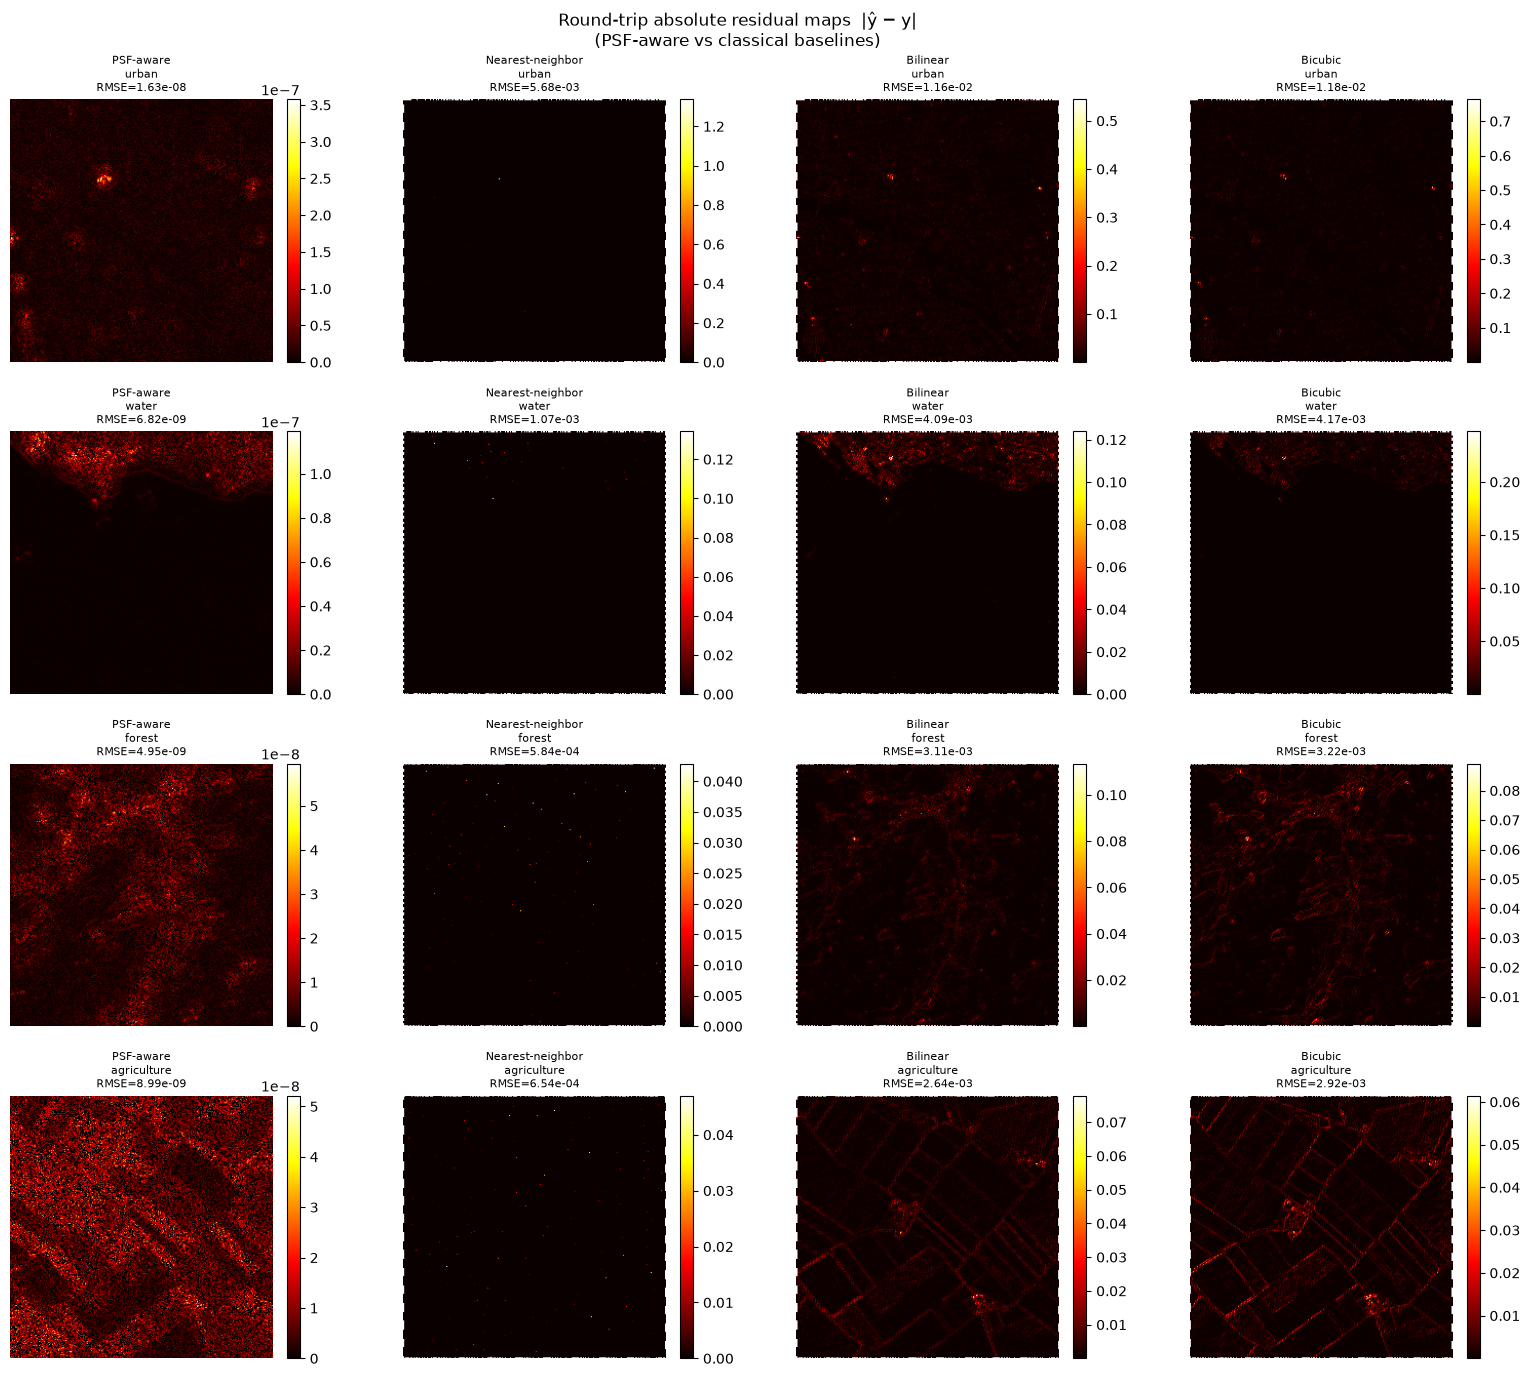

In [13]:
def plot_roundtrip_residuals(force=False):
    methods   = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
    col_labels = ["PSF-aware", "Nearest-neighbor", "Bilinear", "Bicubic"]
    scenes    = list(benchmark_coordinates.keys())
    nrows     = len(scenes)
    ncols     = len(methods)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for r, scene in enumerate(scenes):
        for c, (method, label) in enumerate(zip(methods, col_labels)):
            ax = axes[r, c]
            try:
                if method == "psf_aware":
                    data = psf_resample_scene(scene, force=force)
                else:
                    cl_method = method.replace("classical_", "")
                    data = classical_resample_scene(scene, method=cl_method, force=force)

                abs_res = np.abs(data["residual"])
                vmax = np.nanpercentile(abs_res, 100)
                vmin = np.nanpercentile(abs_res, 0.0)
                im = ax.imshow(abs_res, cmap="hot", vmin=vmin, vmax=vmax)
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                rmse = float(np.sqrt(np.nanmean(data["residual"] ** 2)))
                ax.set_title(f"{label}\n{scene}\nRMSE={rmse:.2e}", fontsize=8)
            except Exception as exc:
                ax.text(0.5, 0.5, str(exc), transform=ax.transAxes,
                        ha="center", va="center", fontsize=7)
                ax.set_title(f"{label}\n{scene}", fontsize=8)
            ax.axis("off")

    fig.suptitle("Round-trip absolute residual maps  |ŷ − y|\n"
                 "(PSF-aware vs classical baselines)", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "roundtrip_residuals_all_methods.pdf", dpi=150, bbox_inches="tight")
    fig.savefig(FIG_DIR / "roundtrip_residuals_all_methods.png", dpi=150, bbox_inches="tight")
    print("Saved to figures/")
    return fig

fig_residuals = plot_roundtrip_residuals()
plt.show()


### Figure — Round-trip PSD comparison (all methods)

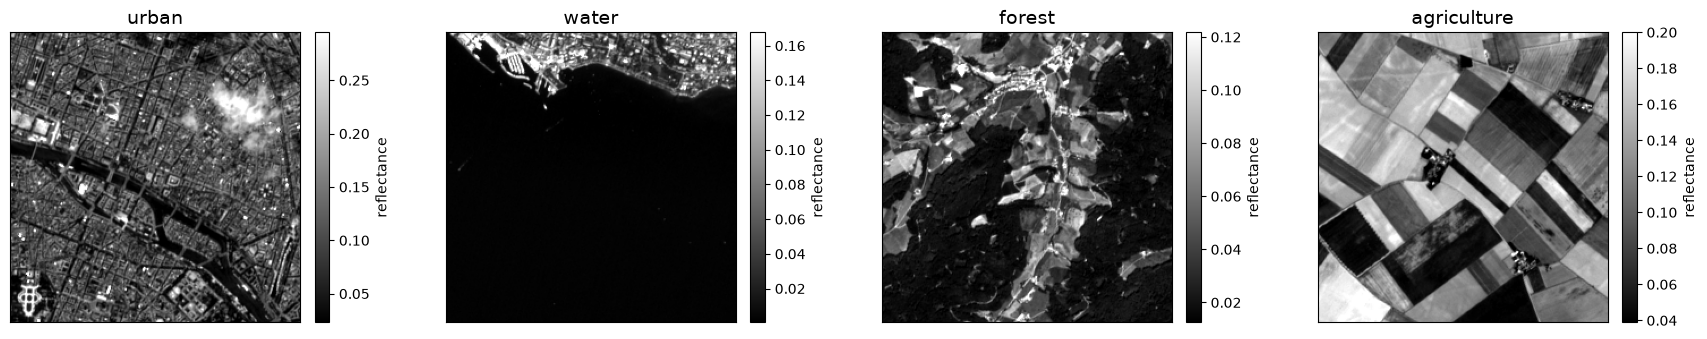

In [14]:
methods   = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS]
col_labels = ["PSF-aware", "Nearest-neighbor", "Bilinear", "Bicubic"]
scenes    = list(benchmark_coordinates.keys())
ncols     = len(scenes)
nrows     = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.5 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

for r, scene in enumerate(scenes):
    c=0
    ax = axes[c,r]
    data = psf_resample_scene(scene, force=False)
    abs_res = data['original']
    vmax = np.nanpercentile(abs_res, 99)
    vmin = np.nanpercentile(abs_res, 1.0)
    im = ax.imshow(abs_res, cmap="grey", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,label='reflectance')
    rmse = float(np.sqrt(np.nanmean(data["residual"] ** 2)))
    ax.set_title(f"{scene}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / "scene_types.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "scene_types.png", dpi=200, bbox_inches="tight")

## 11. ESRI World Imagery sampler

Used as the latent spatial texture in the synthetic detector experiment.


In [15]:
import io, math, requests
from PIL import Image

ESRI_WORLD_IMAGERY = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}"
)
ESRI_TILE_CACHE_DIR = DATA_DIR / "esri_tile_cache"
ESRI_TILE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def latlon_to_xyz_frac(lat, lon, z):
    lat = np.asarray(lat, dtype=np.float64)
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.clip(lat, -85.05112878, 85.05112878)
    n   = 2 ** int(z)
    xf  = (lon + 180.0) / 360.0 * n
    lat_rad = np.radians(lat)
    yf  = (1.0 - np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad)) / math.pi) / 2.0 * n
    return xf, yf

def xyz_frac_to_tile_pixel(xf, yf, tile_size=256):
    xt = np.floor(xf).astype(np.int64)
    yt = np.floor(yf).astype(np.int64)
    px = np.clip(np.floor((xf - xt) * tile_size).astype(np.int64), 0, tile_size - 1)
    py = np.clip(np.floor((yf - yt) * tile_size).astype(np.int64), 0, tile_size - 1)
    return xt, yt, px, py

class EsriTileCache:
    def __init__(self, cache_dir=ESRI_TILE_CACHE_DIR, user_agent="research-sampler/1.0"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.memory_cache = {}
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent})

    def _tile_path(self, z, x, y):
        return self.cache_dir / f"z{int(z)}" / f"x{int(x)}" / f"y{int(y)}.jpg"

    def get_tile(self, z, x, y, timeout=20):
        key = (int(z), int(x), int(y))
        if key in self.memory_cache:
            return self.memory_cache[key]
        path = self._tile_path(*key)
        if path.exists():
            img = Image.open(path).convert("RGB")
            self.memory_cache[key] = img
            return img
        url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
        resp = self.session.get(url, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        path.parent.mkdir(parents=True, exist_ok=True)
        img.save(path, quality=95)
        self.memory_cache[key] = img
        return img

_ESRI_TILE_CACHE = EsriTileCache()

def rgb_to_luminance(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    lum = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
    return np.clip(lum / 255.0, 0.0, 1.0).astype(np.float32)

def sample_esri_world_imagery(lat, lon, zoom=17, tile_size=256, cache=None):
    if cache is None:
        cache = _ESRI_TILE_CACHE
    lat_arr = np.asarray(lat, dtype=np.float64)
    lon_arr = np.asarray(lon, dtype=np.float64)
    if lat_arr.shape != lon_arr.shape:
        raise ValueError("lat and lon must have the same shape.")
    original_shape = lat_arr.shape
    lat_flat, lon_flat = lat_arr.ravel(), lon_arr.ravel()
    xf, yf  = latlon_to_xyz_frac(lat_flat, lon_flat, zoom)
    xt, yt, px, py = xyz_frac_to_tile_pixel(xf, yf, tile_size=tile_size)
    rgb = np.full((lat_flat.size, 3), np.nan, dtype=np.float32)
    tile_pairs   = np.stack([xt, yt], axis=1)
    unique_tiles, inverse = np.unique(tile_pairs, axis=0, return_inverse=True)
    for tile_index, (x_tile, y_tile) in enumerate(unique_tiles):
        sel = np.where(inverse == tile_index)[0]
        try:
            arr = np.asarray(cache.get_tile(zoom, int(x_tile), int(y_tile)), dtype=np.float32)
            rgb[sel, :] = arr[py[sel], px[sel], :]
        except Exception as exc:
            print(f"[WARN] ESRI tile z={zoom} x={int(x_tile)} y={int(y_tile)}: {exc}")
    return rgb.reshape(original_shape + (3,)).astype(np.float32)

def sample_esri_lonlat(lon, lat, scene_name=None, zoom=17, as_gray=True, chunk_size=1_000_000):
    lon_arr, lat_arr = np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)
    if lon_arr.shape != lat_arr.shape:
        raise ValueError("lon and lat must have the same shape.")
    shape    = lon_arr.shape
    lon_flat = lon_arr.ravel(); lat_flat = lat_arr.ravel(); n = lon_flat.size
    out = np.full(n, np.nan, dtype=np.float32) if as_gray else np.full((n, 3), np.nan, dtype=np.float32)
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        rgb  = sample_esri_world_imagery(lat_flat[start:stop], lon_flat[start:stop], zoom=zoom, cache=_ESRI_TILE_CACHE)
        if as_gray:
            out[start:stop] = rgb_to_luminance(rgb)
        else:
            out[start:stop, :] = rgb.astype(np.float32) / 255.0
    return out.reshape(shape) if as_gray else out.reshape(shape + (3,))


## 12. Synthetic detector experiment — helpers

In [16]:
def fwhm_to_sigma(fwhm):
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def make_highres_axis(axis, oversample=4):
    axis = np.asarray(axis, dtype=np.float64)
    d = np.nanmedian(np.diff(axis))
    offsets = (np.arange(oversample) + 0.5) / oversample - 0.5
    return (axis[:, None] + offsets[None, :] * d).reshape(axis.size * oversample)

def block_mean_2d(img_hr, oversample=4):
    ny_hr, nx_hr = img_hr.shape
    ny = ny_hr // oversample; nx = nx_hr // oversample
    img_hr = img_hr[:ny * oversample, :nx * oversample]
    return img_hr.reshape(ny, oversample, nx, oversample).mean(axis=(1, 3))

def align_hpx_values(reference_ids, reference_values, estimated_ids, estimated_values):
    ref = pd.DataFrame({"cell_id": reference_ids.astype(np.int64), "reference": reference_values})
    est = pd.DataFrame({"cell_id": estimated_ids.astype(np.int64), "estimate": estimated_values})
    return ref.merge(est, on="cell_id", how="inner")


### 12.1 Build synthetic detector products (ESRI latent field)

In [17]:
def build_synthetic_detector_products(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, central_size=CENTRAL_SIZE, force=True
):
    """
    Build four synthetic products from an ESRI latent field.

    Returns
    -------
    dict with keys: utm_ref_no_psf, utm_det_psf, hpx_parent_ids,
                    hpx_ref_no_psf, hpx_det_psf, metadata.
    """
    if hp is None:
        raise ImportError("healpy is required for the synthetic detector test.")

    out_npz = DATA_DIR / f"{scene_name}_synthetic_detector_level{level}_os{oversample}_fwhm{fwhm_m:.1f}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon_coarse, lat_coarse, da = load_scene_patch(scene_name)
    img0 = central_crop(img, central_size)
    lon0 = central_crop(lon_coarse, central_size)
    lat0 = central_crop(lat_coarse, central_size)

    x0 = central_crop(np.tile(da.x.values[None, :], (da.y.size, 1)), central_size)[0, :]
    y0 = central_crop(np.tile(da.y.values[:, None], (1, da.x.size)), central_size)[:, 0]

    x_hr = make_highres_axis(x0, oversample=oversample)
    y_hr = make_highres_axis(y0, oversample=oversample)
    xx_hr, yy_hr = np.meshgrid(x_hr, y_hr, indexing="xy")

    crs_utm = da.crs_code
    t_to_wgs   = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    t_from_wgs = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    lon_hr, lat_hr = t_to_wgs.transform(xx_hr, yy_hr)

    esri_hr = sample_esri_lonlat(lon_hr, lat_hr, scene_name=scene_name).astype(np.float32)

    dx_hr = abs(np.nanmedian(np.diff(x_hr)))
    dy_hr = abs(np.nanmedian(np.diff(y_hr)))
    print(dx_hr,dy_hr)
    sigma_m   = fwhm_to_sigma(fwhm_m)
    sigma_pix = sigma_m / np.sqrt(dx_hr * dy_hr)
    esri_psf_hr = gaussian_filter(esri_hr, sigma=sigma_pix, mode="reflect")

    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.imshow(esri_hr)
    plt.subplot(1,2,2)
    plt.imshow(esri_psf_hr)
    
    utm_ref_no_psf = block_mean_2d(esri_hr,     oversample=oversample)
    utm_det_psf    = block_mean_2d(esri_psf_hr, oversample=oversample)

    nside       = 2 ** level
    nside_child = 2 ** (level + 2)
    parent_ids = np.unique(hp.ang2pix(nside, lon_hr.ravel(), lat_hr.ravel(),
                                      lonlat=True, nest=True)).astype(np.int64)

    child_offsets = np.arange(oversample ** 2, dtype=np.int64)
    child_ids_flat = (parent_ids[:, None] * (oversample ** 2) + child_offsets[None, :]).reshape(-1)

    child_lon, child_lat = hp.pix2ang(nside_child, child_ids_flat, lonlat=True, nest=True)
    child_x, child_y    = t_from_wgs.transform(child_lon, child_lat)

    interp_esri = prepare_regular_interpolator(y_hr, x_hr, esri_hr)
    interp_psf  = prepare_regular_interpolator(y_hr, x_hr, esri_psf_hr)

    pts = np.column_stack([child_y, child_x])
    child_ref = interp_esri(pts).reshape(parent_ids.size, oversample ** 2)
    child_psf = interp_psf(pts).reshape(parent_ids.size, oversample ** 2)

    hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
    hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, oversample=oversample, fwhm_m=fwhm_m,
        x=x0.astype(np.float32), y=y0.astype(np.float32),
        lon=lon0.astype(np.float32), lat=lat0.astype(np.float32),
        utm_ref_no_psf=utm_ref_no_psf.astype(np.float32),
        utm_det_psf=utm_det_psf.astype(np.float32),
        hpx_parent_ids=parent_ids,
        hpx_ref_no_psf=hpx_ref_no_psf,
        hpx_det_psf=hpx_det_psf,
    )
    return dict(np.load(out_npz, allow_pickle=True))


In [18]:
from healpix_geo.nested import healpix_to_lonlat

def heal_local_fft(lon,lat,cell_ids,values,level=20,interpol=None,data=None,ref=None):
    
    lonh,lath=healpix_to_lonlat(cell_ids,level)

    if interpol is not None:
        
        values=griddata(np.column_stack([lon.flatten(), lat.flatten()]),
                      values.flatten().astype(np.float64),
                      (lonh.flatten(), lath.flatten()),
                      fill_value=0.0, 
                      method=interpol)
        if ref is not None:
            values-=ref
    if data is None:
        data=griddata(np.column_stack([lonh, lath]),
                      values.astype(np.float64),
                      (lon.flatten(), lat.flatten()),
                      fill_value=0.0, 
                      method="linear").reshape(lon.shape)
    filter=np.hanning(lon.shape[0])
    data = data*np.sqrt(filter[None,:]*filter[:,None])
    data[np.isnan(data)]=0.0
    fdata = np.fft.fft2(data)
    fdata = np.fft.fftshift(fdata*np.conjugate(fdata)).real

    x=np.arange(lon.shape[0])-lon.shape[0]//2
    r=np.sqrt(x[None,:]**2+x[:,None]**2).astype('int')
    
    return np.bincount(r.flatten(),r.flatten())/(np.bincount(r.flatten())),2*np.pi**2*np.bincount(r.flatten(),fdata.flatten())/(lonh.shape[0]*np.bincount(r.flatten()))

### 12.2 PSF-aware resampler on synthetic observation

In [19]:
def run_synthetic_psf_resampler_test(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM , lam=LAMBDA, max_iter=MAX_ITER,
    threshold=THRESHOLD, force=True,fwhm_resampler=FWHM,
):
    if PSFResampler is None:
        raise ImportError("PSFResampler is not available.")
    if hp is None:
        raise ImportError("healpy is required.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, 
                                                 force=force)

    out_npz = DATA_DIR / (
        f"{scene_name}_synthetic_psf_resampler_level{level}"
        f"_fwhmop{fwhm_resampler:.2f}_lam{lam:.4g}.npz"
    )  # fwhm_resampler/lam included so mismatched-PSF runs don't collide with the matched-PSF cache
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    y   = products["utm_det_psf"]
    lon = products["lon"]; lat = products["lat"]

    resampler = PSFResampler(
        lon_deg=lon.reshape(-1).astype("float64"),
        lat_deg=lat.reshape(-1).astype("float64"),
        level=level, threshold=threshold, verbose=True,
        ellipsoid="sphere", sigma_m=fwhm_resampler,
    )
    result = resampler.resample(y.reshape(-1), lam=lam, max_iter=max_iter)

    aligned_no_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_ref_no_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data),
    )
    aligned_psf = align_hpx_values(
        products["hpx_parent_ids"], products["hpx_det_psf"],
        np.asarray(result.cell_ids), np.asarray(result.cell_data),
    )

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level,
        estimated_cell_ids=np.asarray(result.cell_ids).astype(np.int64),
        estimated_cell_data=np.asarray(result.cell_data).astype(np.float32),
        aligned_no_psf_cell_ids=aligned_no_psf["cell_id"].to_numpy(dtype=np.int64),
        aligned_no_psf_reference=aligned_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=aligned_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=aligned_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=aligned_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.3 Classical resampling on synthetic PSF observation

Apply nearest/bilinear/bicubic interpolation to the PSF-blurred synthetic observation
(`utm_det_psf`) and compare the resulting HEALPix values against the ESRI ground-truth
HEALPix fields (`hpx_ref_no_psf` and `hpx_det_psf`).


In [20]:
def run_classical_synthetic_test(scene_name, method="linear", level=HEALPIX_LEVEL,
                                    oversample=4, fwhm_m=FWHM , force=True):
    """
    Classical (geometric) resampling of the synthetic PSF-blurred observation to HEALPix.

    The PSF-blurred UTM image (utm_det_psf) is interpolated at HEALPix cell centres
    using the specified method. Results are aligned with the ESRI reference fields
    for comparison in Table I.
    """
    if hp is None:
        raise ImportError("healpy is required.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m, force=force)

    out_npz = DATA_DIR / f"{scene_name}_synthetic_classical_{method}_level{level}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    # Input: the PSF-blurred observation on the UTM grid
    utm_det = products["utm_det_psf"]
    lon     = products["lon"].astype(np.float64)
    lat     = products["lat"].astype(np.float64)

    # Get HEALPix parent cell IDs from the latent-field reference
    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside      = 2 ** level

    # Cell centres in geographic coords
    hpx_lon, hpx_lat = hp.pix2ang(nside, parent_ids, lonlat=True, nest=True)

    # Build a UTM CRS from the first scene DataArray
    _, _, _, da = load_scene_patch(scene_name)
    crs_utm = da.crs_code
    t_fwd   = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    # Reconstruct 1-D UTM axes from the central crop
    x0, y0 = get_utm_axes(da)

    # Forward: interpolate utm_det at HEALPix cell centres
    if method in ("nearest", "linear"):
        interp_fwd = prepare_regular_interpolator(y0, x0, utm_det, method=method)
        hpx_values = interp_fwd(np.column_stack([hpx_y, hpx_x]))
    else:
        xx_utm, yy_utm = np.meshgrid(x0, y0)
        hpx_values = griddata(
            points=np.column_stack([xx_utm.ravel(), yy_utm.ravel()]),
            values=utm_det.ravel(),
            xi=np.column_stack([hpx_x, hpx_y]),
            method=method,
        )

    # Fill NaN values
    if np.any(~np.isfinite(hpx_values)):
        interp_nn  = prepare_regular_interpolator(y0, x0, utm_det, method="nearest")
        hpx_nn     = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    # Align with ESRI reference fields
    estimated_ids = parent_ids.copy()
    al_no_psf = align_hpx_values(
        parent_ids, products["hpx_ref_no_psf"], estimated_ids, hpx_values)
    al_psf    = align_hpx_values(
        parent_ids, products["hpx_det_psf"],    estimated_ids, hpx_values)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, method=method,
        estimated_cell_ids=estimated_ids,
        estimated_cell_data=hpx_values.astype(np.float32),
        aligned_no_psf_reference=al_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=al_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=al_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=al_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.3b Richardson-Lucy deconvolution (classical PSF-aware baseline)

A second, purely classical PSF-aware baseline: Richardson-Lucy deconvolution
(`skimage.restoration.richardson_lucy`), applied directly on the UTM grid
using the **true, matched** generation PSF (an idealized best case for this
method), followed by bilinear resampling to HEALPix cell centres for a
like-for-like comparison with the other rows of Table I.


In [21]:
def build_gaussian_psf_kernel(fwhm_m, pixel_size_m, radius_sigma=4.0):
    """2-D normalized Gaussian PSF kernel, in pixel units, for richardson_lucy."""
    sigma_pix = fwhm_to_sigma(fwhm_m) / pixel_size_m
    radius = max(1, int(np.ceil(radius_sigma * sigma_pix)))
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    return kernel / kernel.sum()


def run_richardson_lucy_synthetic_test(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, num_iter=RICHARDSON_LUCY_ITER, force=True,
):
    """
    Richardson-Lucy deconvolution of the synthetic PSF-blurred UTM observation,
    using the *true* generation PSF (matched, idealized case), followed by
    bilinear resampling to HEALPix cell centres. Results are aligned with the
    ESRI reference fields for comparison in Table I, exactly like the classical
    geometric baselines.
    """
    if richardson_lucy is None:
        raise ImportError("scikit-image richardson_lucy is not available.")
    if hp is None:
        raise ImportError("healpy is required.")

    products = build_synthetic_detector_products(scene_name, level=level,
                                                 oversample=oversample, fwhm_m=fwhm_m,
                                                 force=force)

    out_npz = DATA_DIR / f"{scene_name}_synthetic_richardson_lucy_level{level}_iter{num_iter}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    utm_det = products["utm_det_psf"].astype(np.float64)

    parent_ids = products["hpx_parent_ids"].astype(np.int64)
    nside      = 2 ** level

    _, _, _, da = load_scene_patch(scene_name)
    x0, y0 = get_utm_axes(da)
    pixel_size_m = abs(np.nanmedian(np.diff(x0)))
    psf_kernel = build_gaussian_psf_kernel(fwhm_m, pixel_size_m)

    # richardson_lucy expects a non-negative image; rescale to [0, 1] and back.
    vmin, vmax = float(np.nanmin(utm_det)), float(np.nanmax(utm_det))
    scale = (vmax - vmin) if vmax > vmin else 1.0
    img01 = np.clip((utm_det - vmin) / scale, 0.0, 1.0)
    deconv01 = richardson_lucy(img01, psf_kernel, num_iter=num_iter, clip=False)
    deconv = deconv01 * scale + vmin

    hpx_lon, hpx_lat = hp.pix2ang(nside, parent_ids, lonlat=True, nest=True)
    crs_utm = da.crs_code
    t_fwd   = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)

    interp_fwd = prepare_regular_interpolator(y0, x0, deconv, method="linear")
    hpx_values = interp_fwd(np.column_stack([hpx_y, hpx_x]))
    if np.any(~np.isfinite(hpx_values)):
        interp_nn  = prepare_regular_interpolator(y0, x0, deconv, method="nearest")
        hpx_nn     = interp_nn(np.column_stack([hpx_y, hpx_x]))
        hpx_values = np.where(np.isfinite(hpx_values), hpx_values, hpx_nn)

    al_no_psf = align_hpx_values(parent_ids, products["hpx_ref_no_psf"], parent_ids, hpx_values)
    al_psf    = align_hpx_values(parent_ids, products["hpx_det_psf"],    parent_ids, hpx_values)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, num_iter=num_iter,
        estimated_cell_ids=parent_ids,
        estimated_cell_data=hpx_values.astype(np.float32),
        aligned_no_psf_reference=al_no_psf["reference"].to_numpy(dtype=np.float32),
        aligned_no_psf_estimate=al_no_psf["estimate"].to_numpy(dtype=np.float32),
        aligned_psf_reference=al_psf["reference"].to_numpy(dtype=np.float32),
        aligned_psf_estimate=al_psf["estimate"].to_numpy(dtype=np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


### 12.4 Table I — Synthetic detector metrics (all methods)

Rows: scene × comparison pair.
Columns: one per method (PSF-aware + classical baselines).


In [22]:
def run_all_synthetic_metrics(force=True):
    rows = []
    methods_classical = CLASSICAL_METHODS
    fwhm_m = FWHM 

    for scene in benchmark_coordinates:
        products = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)

        # ── PSF-aware, matched operator PSF ─────────────────────────────────
        try:
            res_psf = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=fwhm_m, lam=LAMBDA, force=force)
            rows.append(scalar_metrics(
                res_psf["aligned_no_psf_reference"], res_psf["aligned_no_psf_estimate"],
                scene, "psf_aware", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_psf["aligned_psf_reference"], res_psf["aligned_psf_estimate"],
                scene, "psf_aware", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware synthetic {scene}: {exc}")

        # ── PSF-aware, mis-specified operator PSF: +50% (wider than truth) ──
        try:
            res_wide = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                lam=LAMBDA, force=force)
            rows.append(scalar_metrics(
                res_wide["aligned_no_psf_reference"], res_wide["aligned_no_psf_estimate"],
                scene, "psf_aware_wide", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_wide["aligned_psf_reference"], res_wide["aligned_psf_estimate"],
                scene, "psf_aware_wide", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware (+50% PSF) synthetic {scene}: {exc}")

        # ── PSF-aware, mis-specified operator PSF: -50% (narrower than truth) ─
        try:
            res_narrow = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                lam=LAMBDA_PSF_AWARE_NARROW, force=force)
            rows.append(scalar_metrics(
                res_narrow["aligned_no_psf_reference"], res_narrow["aligned_no_psf_estimate"],
                scene, "psf_aware_narrow", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_narrow["aligned_psf_reference"], res_narrow["aligned_psf_estimate"],
                scene, "psf_aware_narrow", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] PSF-aware (-50% PSF) synthetic {scene}: {exc}")

        # ── Richardson-Lucy, matched PSF (classical iterative deconvolution) ─
        try:
            res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=force)
            rows.append(scalar_metrics(
                res_rl["aligned_no_psf_reference"], res_rl["aligned_no_psf_estimate"],
                scene, "richardson_lucy", "estimated_vs_esri_no_psf"))
            rows.append(scalar_metrics(
                res_rl["aligned_psf_reference"], res_rl["aligned_psf_estimate"],
                scene, "richardson_lucy", "estimated_vs_esri_psf"))
        except Exception as exc:
            print(f"[WARN] Richardson-Lucy synthetic {scene}: {exc}")

        # ── Classical ────────────────────────────────────────────────────────
        for m in methods_classical:
            try:
                res_cl = run_classical_synthetic_test(scene, method=m, fwhm_m=fwhm_m, force=force)
                rows.append(scalar_metrics(
                    res_cl["aligned_no_psf_reference"], res_cl["aligned_no_psf_estimate"],
                    scene, f"classical_{m}", "estimated_vs_esri_no_psf"))
                rows.append(scalar_metrics(
                    res_cl["aligned_psf_reference"], res_cl["aligned_psf_estimate"],
                    scene, f"classical_{m}", "estimated_vs_esri_psf"))
            except Exception as exc:
                print(f"[WARN] Classical {m} synthetic {scene}: {exc}")

        # ── ESRI PSF vs ESRI no-PSF (intrinsic degradation, same for all) ───
        rows.append(scalar_metrics(
            products["hpx_ref_no_psf"], products["hpx_det_psf"],
            scene, "esri_psf_degradation", "esri_psf_vs_esri_no_psf"))

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "synthetic_metrics_all_methods.csv", index=False)
    return df

df_synthetic = run_all_synthetic_metrics(force=False)
df_synthetic


,scene,method,comparison,n,rmse,mae,bias,corr,r2
0,urban,psf_aware,estimated_vs_esri_no_psf,169675,0.074514,0.056361,2.631905e-05,0.916892,0.836244
1,urban,psf_aware,estimated_vs_esri_psf,169675,0.046224,0.034934,-1.407377e-06,0.962883,0.877388
2,urban,psf_aware_wide,estimated_vs_esri_no_psf,169675,0.085514,0.065239,2.621895e-05,0.885792,0.784326
3,urban,psf_aware_wide,estimated_vs_esri_psf,169675,0.066593,0.050433,-1.507480e-06,0.925786,0.745520
4,urban,psf_aware_narrow,estimated_vs_esri_no_psf,169478,0.093053,0.071657,-8.542721e-06,0.874520,0.744532
5,urban,psf_aware_narrow,estimated_vs_esri_psf,169478,0.026011,0.019552,-1.939182e-05,0.981209,0.961160
6,urban,richardson_lucy,estimated_vs_esri_no_psf,167797,0.087783,0.067445,1.161506e-04,0.891276,0.772172
7,urban,richardson_lucy,estimated_vs_esri_psf,167797,0.017623,0.013284,1.181712e-04,0.992004,0.982099
8,urban,classical_nearest,estimated_vs_esri_no_psf,167797,0.105896,0.082237,-1.527050e-04,0.826740,0.668456
9,urban,classical_nearest,estimated_vs_esri_psf,167797,0.041685,0.030099,-1.506844e-04,0.949208,0.899847


In [23]:
def format_table_I(df):
    """
    Pivot synthetic metrics into a wide table matching Table I of the paper.
    One block per scene, showing RMSE for each (comparison, method) pair.
    """
    methods = ["psf_aware", "psf_aware_wide", "psf_aware_narrow", "richardson_lucy"] \
        + [f"classical_{m}" for m in CLASSICAL_METHODS]
    method_labels = {
        "psf_aware":        "PSF-aware",
        "psf_aware_wide":   "PSF-aware +50%",
        "psf_aware_narrow": "PSF-aware -50%",
        "richardson_lucy":  "Richardson-Lucy",
        "classical_nearest": "Nearest",
        "classical_linear":  "Bilinear",
        "classical_cubic":   "Bicubic",
    }
    comparisons = ["estimated_vs_esri_no_psf", "estimated_vs_esri_psf"]
    comp_labels = {
        "estimated_vs_esri_no_psf": "Estimated vs. ESRI no-PSF",
        "estimated_vs_esri_psf":    "Estimated vs. ESRI PSF",
    }

    records = []
    for scene in benchmark_coordinates:
        for comp in comparisons:
            row = {"Scene": scene, "Comparison": comp_labels[comp]}
            for m in methods:
                sub = df[(df["scene"] == scene) & (df["method"] == m)
                         & (df["comparison"] == comp)]
                row[f"{method_labels[m]} RMSE"] = sub.iloc[0]["rmse"] if not sub.empty else np.nan
            records.append(row)
        # Intrinsic PSF degradation
        sub_deg = df[(df["scene"] == scene) & (df["method"] == "esri_psf_degradation")]
        row_deg = {"Scene": scene, "Comparison": "ESRI PSF vs. ESRI no-PSF (degradation)"}
        for m in methods:
            row_deg[f"{method_labels[m]} RMSE"] = np.nan
        if not sub_deg.empty:
            row_deg["PSF-aware RMSE"] = sub_deg.iloc[0]["rmse"]
        records.append(row_deg)

    t1 = pd.DataFrame(records).set_index(["Scene", "Comparison"])
    t1.to_csv(TABLE_DIR / "table_I_synthetic.csv")
    try:
        t1.to_latex(TABLE_DIR / "table_I_synthetic.tex", float_format="{:.4f}".format)
    except Exception:
        pass
    return t1

table_I = format_table_I(df_synthetic)
table_I.style.format("{:.4f}", na_rep="—")


## 13. Figure 2 — Synthetic detector visual comparison

Rows: ESRI no-PSF | ESRI PSF | PSF-aware estimated | Nearest | Bilinear | Bicubic.
Columns: four benchmark scenes.


(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
(171626,) (171626,) (171626,)
(171626,) (171626,) (171626,)
(171626,) (171626,) (171626,)
(171626,) (171626,) (171626,)
(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
(171608,) (171608,) (171608,)
(171608,) (171608,) (171608,)
(171608,) (171608,) (171608,)
(171608,) (171608,) (171608,)
(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
(171661,) (171661,) (171661,)
(171661,) (171661,) (171661,)
(171661,) (171661,) (171661,)
(171661,) (171661,) (171661,)
(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
(171612,) (171612,) (171612,)
(171612,) (171612,) (171612,)
(171612,) (171612,) (171612,)
(171612,) (171612,) (171612,)
Saved.


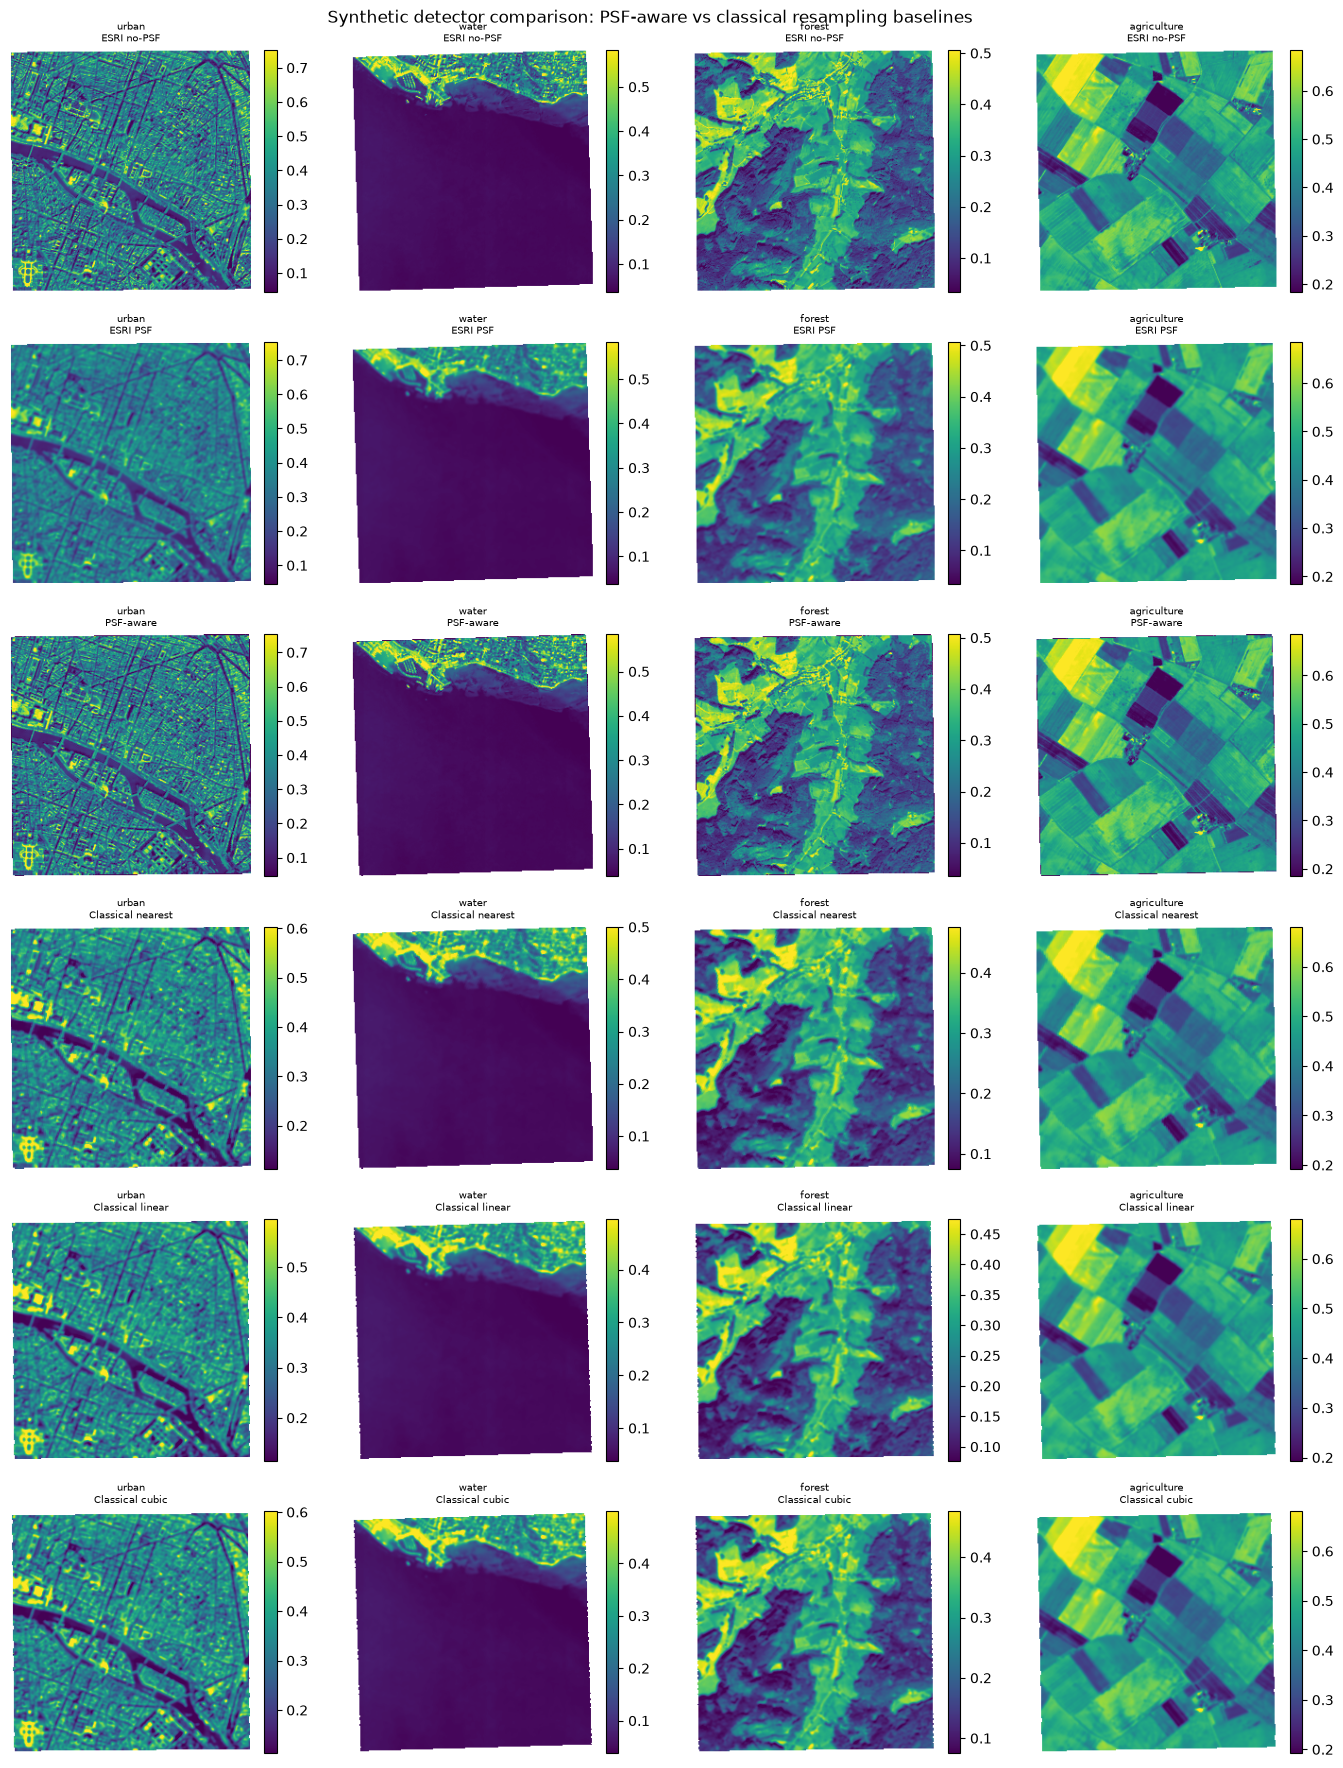

In [24]:
from foscat.Plot import power_spectrum_1d, lgnomproject
from healpix_geo.nested import healpix_to_lonlat

def plot_synthetic_comparison(force=False):
    scenes     = list(benchmark_coordinates.keys())
    row_keys   = ["esri_no_psf", "esri_psf", "psf_aware",
                  "nearest", "linear", "cubic"]
    row_labels = ["ESRI no-PSF (latent)", "ESRI PSF (synthetic obs.)",
                  "PSF-aware HEALPix est.",
                  "Classical nearest", "Classical bilinear", "Classical bicubic"]
    nrows = len(row_keys); ncols = len(scenes)
    fwhm_m = FWHM * 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
    if ncols == 1:
        axes = axes[:, np.newaxis]

    def show_img(ax, img, title, vmin=None, vmax=None,origin='lower'):
        if img is None:
            ax.text(0.5, 0.5, "N/A", transform=ax.transAxes,
                    ha="center", va="center")
        else:
            im = ax.imshow(img, cmap="viridis",
                           vmin=vmin if vmin is not None else np.nanpercentile(img, 1),
                           vmax=vmax if vmax is not None else np.nanpercentile(img, 99),
                           origin=origin)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=7)
        ax.axis("off")

    for c, scene in enumerate(scenes):
        try:
            prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)
            esri_no_psf = prod["utm_ref_no_psf"]
            esri_psf    = prod["utm_det_psf"]
            vmin = float(np.nanpercentile(esri_no_psf, 1))
            vmax = float(np.nanpercentile(esri_no_psf, 99))

            # Common HEALPix square for visualisation
            parent_ids = prod["hpx_parent_ids"]
            nside = 2 ** HEALPIX_LEVEL
            hpx_lon, hpx_lat = hp.pix2ang(nside, parent_ids, lonlat=True, nest=True)
            img, lon, lat, da = load_scene_patch(scene)

            # Helper: render HEALPix values on a square grid
            def hpx_to_img(cell_values,cell_ids=None, npix=256,lon=None,lat=None):
                if cell_ids is not None:
                    lon,lat = healpix_to_lonlat(cell_ids,20, ellipsoid="WGS84")

                print(lon.shape,lat.shape,cell_values.shape)
                xg = np.linspace(lon.min(), lon.max(), npix)
                yg = np.linspace(lat.min(), lat.max(), npix)
                xx, yy = np.meshgrid(xg, yg)

                return griddata(np.column_stack([lon, lat]),
                        cell_values.astype(np.float64),
                        (xx, yy), method="linear")

            # Row 0: ESRI no-PSF (UTM)
            show_img(axes[0, c], hpx_to_img(esri_no_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()), f"{scene}\nESRI no-PSF", vmin, vmax)
            # Row 1: ESRI PSF (UTM)
            show_img(axes[1, c], hpx_to_img(esri_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()),    f"{scene}\nESRI PSF",    vmin, vmax)

            # Row 2: PSF-aware
            try:
                res_psf = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, force=force)
                est_ids  = res_psf["estimated_cell_ids"]
                est_vals = res_psf["estimated_cell_data"]
                # Render on same square as reference
                show_img(axes[2, c], hpx_to_img(est_vals,cell_ids=est_ids), f"{scene}\nPSF-aware", vmin, vmax,origin='lower')
            except Exception as exc:
                show_img(axes[2, c], None, f"{scene}\nPSF-aware\n{exc}")

            # Rows 3-5: Classical
            lonh,lath = healpix_to_lonlat(est_ids,20) #, ellipsoid="WGS84")
            for r_off, method in enumerate(["nearest", "linear", "cubic"]):
                row = 3 + r_off
                try:
                    res_cl = griddata( np.column_stack([lon.flatten(), lat.flatten()]),
                                esri_psf.astype(np.float64).flatten(),
                                (lonh, lath), method=method)
                    img = hpx_to_img(res_cl,cell_ids=est_ids)
                    vmin = float(np.nanpercentile(img, 1))
                    vmax = float(np.nanpercentile(img, 99))
                    show_img(axes[row, c],
                             img,
                             f"{scene}\nClassical {method}", vmin, vmax,origin='lower')
                except Exception as exc:
                    show_img(axes[row, c], None, f"{scene}\n{method}\n{exc}")

        except Exception as exc:
            for r in range(nrows):
                axes[r, c].text(0.5, 0.5, f"Error:\n{exc}",
                                transform=axes[r, c].transAxes,
                                ha="center", va="center", fontsize=7)

    for r, label in enumerate(row_labels):
        axes[r, 0].set_ylabel(label, fontsize=8, rotation=90, labelpad=5)

    fig.suptitle("Synthetic detector comparison: PSF-aware vs classical resampling baselines",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_synthetic_comparison_all_methods.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "fig2_synthetic_comparison_all_methods.png", dpi=150, bbox_inches="tight")
    print("Saved.")
    return fig

fig_synthetic = plot_synthetic_comparison()
plt.show()


### Figure — Synthetic detector PSD: all methods

In [ ]:
def plot_synthetic_psd(force=False):
    scenes   = list(benchmark_coordinates.keys())
    fwhm_m   = FWHM * 2
    methods  = ["psf_aware", "nearest", "linear", "cubic"]
    labels   = ["PSF-aware", "Classical nearest", "Classical bilinear", "Classical bicubic"]
    colors   = ["red", "orange", "green", "purple"]

    fig, axes = plt.subplots(1, len(scenes), figsize=(5 * len(scenes), 4))
    if len(scenes) == 1:
        axes = [axes]

    for ax, scene in zip(axes[0:1], scenes[0:1]):
        prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=force)
        npix=prod["utm_ref_no_psf"].shape[0]
        nu=(np.arange(npix//2-1)+1)/(6.3*npix/2)
        regul=1/(np.pi*npix//2)
        #
        # plots
        #

        # PSF-aware
        try:
            res = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, force=force)
            print(res)
            parent_ids = res['aligned_no_psf_cell_ids']
            nside = 2 ** HEALPIX_LEVEL
            hpx_lon, hpx_lat = hp.pix2ang(nside, parent_ids, lonlat=True, nest=True)
            _, _, _, da = load_scene_patch(scene)
            t_fwd = pyproj.Transformer.from_crs(4326, da.crs_code, always_xy=True)
            hpx_x, hpx_y = t_fwd.transform(hpx_lon, hpx_lat)
            x0, y0 = get_utm_axes(da)

            # align estimated values to parent_ids order
            est_df = pd.DataFrame({"cell_id": res["aligned_no_psf_cell_ids"],
                                   "val": res["aligned_no_psf_estimate"]})
            ref_df = pd.DataFrame({"cell_id": parent_ids})
            merged = ref_df.merge(est_df, on="cell_id", how="left")
            hpx_vals = merged["val"].values

            xx, yy = np.meshgrid(x0, y0)
            img_est = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals,
                               (xx, yy), method="linear")
            if np.any(~np.isfinite(img_est)):
                img_nn = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals,
                                  (xx, yy), method="nearest")
                img_est = np.where(np.isfinite(img_est), img_est, img_nn)

            img_residu=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_no_psf_estimate"] - res["aligned_no_psf_reference"],
                               (xx, yy), method="cubic")
            img_no_psf=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_no_psf_reference"],
                               (xx, yy), method="cubic")
            img_psf=  griddata(np.column_stack([hpx_x, hpx_y]), res["aligned_psf_reference"],
                               (xx, yy), method="cubic")
            print(img_psf.shape)
            k_noP, p_noP = psd1d_numpy(img_no_psf)
            k_psf, p_psf = psd1d_numpy(img_psf)
            k_e, p_e        = psd1d_numpy(img_est)
            k_e, p_e_residu = psd1d_numpy(img_residu)
            #
            # plots
            #
            ax.loglog(nu, p_noP*regul, "k-",  lw=2, label="ESRI no-PSF (latent)")
            ax.loglog(nu, p_psf*regul, "k--", lw=2, label="ESRI PSF (obs.)")
            ax.loglog(nu, p_e*regul, color="red", label="PSF-aware")
            ax.loglog(nu, p_e_residu*regul, ':',color="red", label="PSF-aware residu")
            
        except Exception as exc:
            print(f"[WARN] PSF-aware PSD {scene}: {exc}")

        # Classical
        for method, label, color in zip(["nearest", "linear", "cubic"],
                                        ["Classical nearest", "Classical bilinear", "Classical bicubic"],
                                        ["orange", "green", "purple"]):
            try:
                res_cl = run_classical_synthetic_test(scene, method=method,
                                                       fwhm_m=fwhm_m, force=force)
                hpx_vals_cl = res_cl["estimated_cell_data"]
                img_cl = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals_cl,
                                  (xx, yy), method="linear")
                if np.any(~np.isfinite(img_cl)):
                    img_cl_nn = griddata(np.column_stack([hpx_x, hpx_y]), hpx_vals_cl,
                                         (xx, yy), method="nearest")
                    img_cl = np.where(np.isfinite(img_cl), img_cl, img_cl_nn)
                k_cl, p_cl        = psd1d_numpy(img_cl) 
                k_cl, p_cl_residu = psd1d_numpy(img_cl-prod["utm_ref_no_psf"]) 
                #
                # plots
                #
                ax.loglog(nu, p_cl*regul, color=color, label=label)
                ax.loglog(nu, p_cl_residu*regul,':', color=color, label=label+" residu")
                
            except Exception as exc:
                print(f"[WARN] Classical {method} PSD {scene}: {exc}")

        ax.set_title(scene)
        ax.set_xlabel("Spatial frequency $m^{-1}$")
        ax.set_ylabel("Signal PSD $radiance^2$")
        if scene=='urban':
            ax.legend(fontsize=8,frameon=0,ncol=2)
        ax.grid(True, which="both", alpha=0.3)

    fig.suptitle("Synthetic detector 1D power spectra — all methods", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "synthetic_psd_all_methods.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "synthetic_psd_all_methods.png", dpi=200, bbox_inches="tight")
    return fig

fig_psd_synth = plot_synthetic_psd()
plt.show()


{'scene': array('urban', dtype='<U5'), 'level': array(20), 'estimated_cell_ids': array([750698356055, 750698356059, 750698356060, ..., 750701412387,
       750701412388, 750701412392], shape=(171626,)), 'estimated_cell_data': array([0.       , 0.       , 0.       , ..., 0.       , 0.2629555,
       0.244688 ], shape=(171626,), dtype=float32), 'aligned_no_psf_cell_ids': array([750698356061, 750698356062, 750698356063, ..., 750701412384,
       750701412385, 750701412386], shape=(169853,)), 'aligned_no_psf_reference': array([0.49559104, 0.4732621 , 0.49702877, ..., 0.21020307, 0.30626684,
       0.11995783], shape=(169853,), dtype=float32), 'aligned_no_psf_estimate': array([0.48440182, 0.49167928, 0.4929519 , ..., 0.19692689, 0.2201916 ,
       0.16223228], shape=(169853,), dtype=float32), 'aligned_psf_reference': array([0.47680965, 0.44506964, 0.44108444, ..., 0.18660553, 0.21561143,
       0.18267152], shape=(169853,), dtype=float32), 'aligned_psf_estimate': array([0.48440182, 0.491679

/tmp/ipykernel_6384/1169417255.py:3: RuntimeWarning: Mean of empty slice
  arr = np.where(np.isfinite(arr), arr, np.nanmean(arr))
/opt/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [48]:
scene   = 'urban'
fwhm_m   = FWHM 
prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=False)
res = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, fwhm_resampler= fwhm_m, 
                                       force=False, max_iter=30,lam=0.0)
res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=False)
res_wide = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                lam=LAMBDA, force=False)
res_narrow = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                lam=LAMBDA_PSF_AWARE_NARROW, force=False)

img, _, _, _ = load_scene_patch(scene)

nu1,cl0=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_no_psf_reference'],data=img*2)
nu1,cl1=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_no_psf_reference'])
nu2,cl2=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_psf_reference'])
nu2,cl3=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_psf_estimate'])
nu2,cl3rl=heal_local_fft(prod['lon'],prod['lat'],res_rl['estimated_cell_ids'],
                       res_rl['aligned_psf_estimate'])
nu2,cl3w=heal_local_fft(prod['lon'],prod['lat'],res_wide['aligned_no_psf_cell_ids'],
                       res_wide['aligned_psf_estimate'])
nu2,cl3n=heal_local_fft(prod['lon'],prod['lat'],res_narrow['aligned_no_psf_cell_ids'],
                       res_narrow['aligned_psf_estimate'])

nu1,cl4=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_psf_estimate']-res['aligned_no_psf_reference'])

nu2,cl4rl=heal_local_fft(prod['lon'],prod['lat'],res_rl['estimated_cell_ids'],
                       res_rl['aligned_psf_estimate']-res_rl['aligned_no_psf_reference'])
nu2,cl4w=heal_local_fft(prod['lon'],prod['lat'],res_wide['aligned_no_psf_cell_ids'],
                       res_wide['aligned_no_psf_estimate']-res_wide['aligned_no_psf_reference'])
nu2,cl4n=heal_local_fft(prod['lon'],prod['lat'],res_narrow['aligned_no_psf_cell_ids'],
                       res_narrow['aligned_no_psf_estimate']-res_narrow['aligned_no_psf_reference'])

nu2,cl5=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       res['aligned_psf_reference']-res['aligned_no_psf_reference'])


nu2,cl6=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='nearest')
nu2,cl7=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='linear' )
nu2,cl8=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='cubic')

nu2,cl6b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='nearest',ref=res['aligned_no_psf_reference'])
nu2,cl7b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='linear' ,ref=res['aligned_no_psf_reference'])
nu2,cl8b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                       prod['utm_det_psf'],interpol='cubic', ref=res['aligned_no_psf_reference'])

In [44]:
res_wide

{'scene': array('urban', dtype='<U5'),
 'level': array(20),
 'estimated_cell_ids': array([750698356053, 750698356054, 750698356055, ..., 750701412393,
        750701412394, 750701412395], shape=(173371,)),
 'estimated_cell_data': array([0., 0., 0., ..., 0., 0., 0.], shape=(173371,), dtype=float32),
 'aligned_no_psf_cell_ids': array([750698356061, 750698356062, 750698356063, ..., 750701412384,
        750701412385, 750701412386], shape=(169853,)),
 'aligned_no_psf_reference': array([0.49559104, 0.4732621 , 0.49702877, ..., 0.21020307, 0.30626684,
        0.11995783], shape=(169853,), dtype=float32),
 'aligned_no_psf_estimate': array([0.46803528, 0.49518907, 0.49528772, ..., 0.16401158, 0.22252259,
        0.1934025 ], shape=(169853,), dtype=float32),
 'aligned_psf_reference': array([0.47680965, 0.44506964, 0.44108444, ..., 0.18660553, 0.21561143,
        0.18267152], shape=(169853,), dtype=float32),
 'aligned_psf_estimate': array([0.46803528, 0.49518907, 0.49528772, ..., 0.16401158, 0.2

(65536,) (65536,) (65536,)
(65536,) (65536,) (65536,)
(171626,) (171626,) (171626,)
(169853,) (169853,) (169853,)
(173371,) (173371,) (173371,)
(169488,) (169488,) (169488,)
(169488,) (169488,) (169488,)
(169488,) (169488,) (169488,)
(169488,) (169488,) (169488,)


/tmp/ipykernel_6384/1035934702.py:133: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()


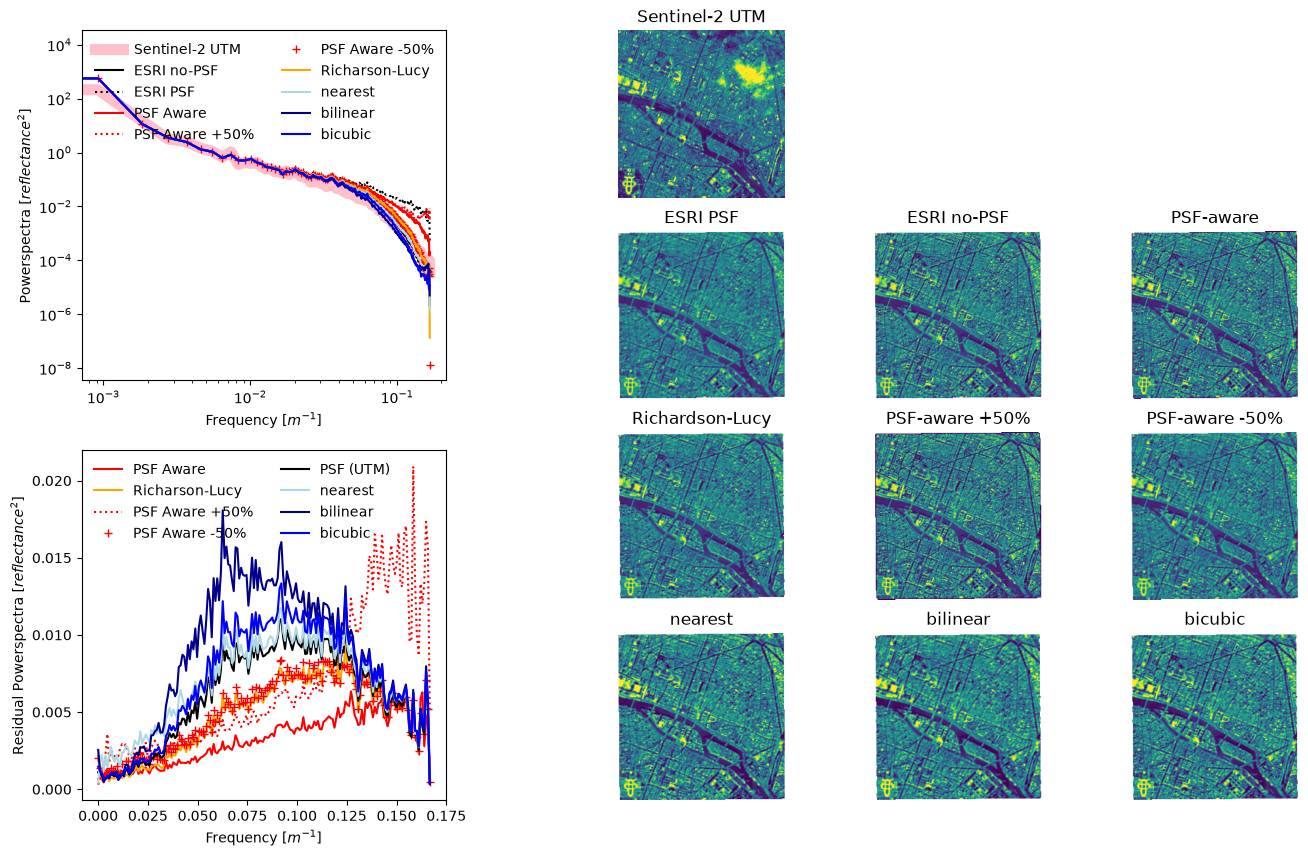

In [53]:

def show_img(ax, img, title, vmin=None, vmax=None,origin='lower'):
    if img is None:
        ax.text(0.5, 0.5, "N/A", transform=ax.transAxes,
                    ha="center", va="center", fontsize="large")
    else:
        im = ax.imshow(img, cmap="viridis",
                           vmin=vmin if vmin is not None else np.nanpercentile(img, 1),
                           vmax=vmax if vmax is not None else np.nanpercentile(img, 99),
                           origin=origin)
        #plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

scene='urban'
prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=False)
esri_no_psf = prod["utm_ref_no_psf"]
esri_psf    = prod["utm_det_psf"]
vmin = float(np.nanpercentile(esri_no_psf, 1))
vmax = float(np.nanpercentile(esri_no_psf, 99))
            
# Common HEALPix square for visualisation
            
parent_ids = prod["hpx_parent_ids"]
            
nside = 2 ** HEALPIX_LEVEL
            
hpx_lon, hpx_lat = hp.pix2ang(nside, parent_ids, lonlat=True, nest=True)
            
img, lon, lat, da = load_scene_patch(scene)

fig = plt.figure(figsize=(16,10))
# Helper: render HEALPix values on a square grid
            
def hpx_to_img(cell_values,cell_ids=None, npix=256,lon=None,lat=None):
                if cell_ids is not None:
                    lon,lat = healpix_to_lonlat(cell_ids,20, ellipsoid="WGS84")

                print(lon.shape,lat.shape,cell_values.shape)
                xg = np.linspace(lon.min(), lon.max(), npix)
                yg = np.linspace(lat.min(), lat.max(), npix)
                xx, yy = np.meshgrid(xg, yg)

                return griddata(np.column_stack([lon, lat]),
                        cell_values.astype(np.float64),
                        (xx, yy), method="linear")

            
# Row 0: Sentinel-2 DATA
show_img(plt.subplot(4,5,3), img*3, f"Sentinel-2 UTM", vmin, vmax,origin=None)
# Row 0: ESRI no-PSF (UTM)
show_img(plt.subplot(4,5,9), hpx_to_img(esri_no_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()), f"ESRI no-PSF", vmin, vmax)
# Row 1: ESRI PSF (UTM)
show_img(plt.subplot(4,5,8), hpx_to_img(esri_psf.flatten(),
                                            lon=lon.flatten(),
                                            lat=lat.flatten()),    f"ESRI PSF",    vmin, vmax)
# Row 2: PSF-aware
            
try:
    res_psf = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, force=False)
    est_ids  = res_psf["estimated_cell_ids"]
    est_vals = res_psf["estimated_cell_data"]
    # Render on same square as reference
    show_img(plt.subplot(4,5,10), hpx_to_img(est_vals,cell_ids=est_ids), f"PSF-aware", vmin, vmax,origin='lower')
    
    res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=False)
    est_ids  = res_rl["estimated_cell_ids"]
    est_vals = res_rl["estimated_cell_data"]
    show_img(plt.subplot(4,5,13), hpx_to_img(est_vals,cell_ids=est_ids), f"Richardson-Lucy", vmin, vmax,origin='lower')
    
    res_wide = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                lam=LAMBDA, force=False)
    est_ids  = res_wide["estimated_cell_ids"]
    est_vals = res_wide["estimated_cell_data"]
    show_img(plt.subplot(4,5,14), hpx_to_img(est_vals,cell_ids=est_ids), f"PSF-aware +50%", vmin, vmax,origin='lower')
    res_narrow = run_synthetic_psf_resampler_test(
                scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                lam=LAMBDA_PSF_AWARE_NARROW, force=False)
    est_ids  = res_narrow["estimated_cell_ids"]
    est_vals = res_narrow["estimated_cell_data"]
    show_img(plt.subplot(4,5,15), hpx_to_img(est_vals,cell_ids=est_ids), f"PSF-aware -50%", vmin, vmax,origin='lower')
except Exception as exc:
    show_img(plt.subplot(4,5,8), None, f"{scene}\nPSF-aware\n{exc}")

# Rows 3-5: Classical
lonh,lath = healpix_to_lonlat(est_ids,20) #, ellipsoid="WGS84")
for r_off, method in enumerate(["nearest", "linear", "cubic"]):
    row = 3 
    col = 2 + (r_off)%3
    try:
        res_cl = griddata( np.column_stack([lon.flatten(), lat.flatten()]),
                                esri_psf.astype(np.float64).flatten(),
                                (lonh, lath), method=method)
        img = hpx_to_img(res_cl,cell_ids=est_ids)
        vmin = float(np.nanpercentile(img, 1))
        vmax = float(np.nanpercentile(img, 99))
        if method!='nearest':
            method='bi'+method
        show_img(plt.subplot(4,5,1+row*5+col),
                    img,
                    f"{method}", vmin, vmax,origin='lower')
    except Exception as exc:
        show_img(plt.subplot(4,5,1+row*5+col), None, f"{method}\n{exc}")
        
plt.subplot(2,3,1)
plt.loglog(1/(6*nu2.max())*nu2,cl0,color='pink',lw=8,label='Sentinel-2 UTM')
plt.loglog(1/(6*nu2.max())*nu2,cl2,color='black',label=f"ESRI no-PSF")
plt.loglog(1/(6*nu2.max())*nu2,cl1,':',color='black',label=f"ESRI PSF")
plt.loglog(1/(6*nu2.max())*nu2,cl3,color='r',label='PSF Aware')
plt.loglog(1/(6*nu2.max())*nu2,cl3w,':',color='r',label='PSF Aware +50%')
plt.loglog(1/(6*nu2.max())*nu2,cl3n,'+',color='r',label='PSF Aware -50%')
plt.loglog(1/(6*nu2.max())*nu2,cl3rl,color='orange',label='Richarson-Lucy')
plt.loglog(1/(6*nu2.max())*nu2,cl6,color='lightblue',label='nearest')
plt.loglog(1/(6*nu2.max())*nu2,cl7,color='darkblue',label='bilinear')
plt.loglog(1/(6*nu2.max())*nu2,cl8,color='b',label='bicubic')
plt.ylabel('Powerspectra [$reflectance^{2}$]')
plt.xlabel(r'Frequency [$m^{-1}$]')
plt.legend(frameon=0,ncols=2 )
plt.subplot(2,3,4)
plt.plot(1/(6*nu2.max())*nu2,cl4,color='r',label='PSF Aware')
plt.plot(1/(6*nu2.max())*nu2,cl4rl,color='orange',label='Richarson-Lucy')
plt.plot(1/(6*nu2.max())*nu2,cl4w,':',color='r',label='PSF Aware +50%')
plt.plot(1/(6*nu2.max())*nu2,cl4n,'+',color='r',label='PSF Aware -50%')
plt.plot(1/(6*nu2.max())*nu2,cl5,color='black',label='PSF (UTM)')
plt.plot(1/(6*nu2.max())*nu2,cl6b,color='lightblue',label='nearest')
plt.plot(1/(6*nu2.max())*nu2,cl7b,color='darkblue',label='bilinear')
plt.plot(1/(6*nu2.max())*nu2,cl8b,color='b',label='bicubic')
plt.ylabel('Residual Powerspectra [$reflectance^{2}$]')
plt.xlabel(r'Frequency [$m^{-1}$]')
plt.legend(frameon=0,ncols=2)
fig.tight_layout()
plt.savefig('resample-test.pdf')

/tmp/ipykernel_6384/2208683019.py:93: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()


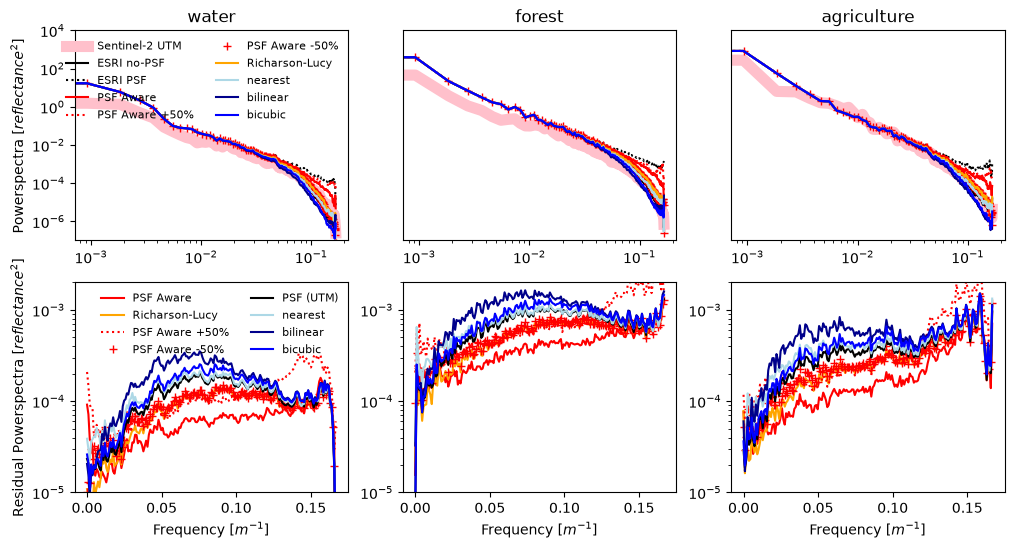

In [55]:
plt.figure(figsize=(12,6))
for c,scene in enumerate(['water','forest','agriculture']):
    fwhm_m   = FWHM 
    prod = build_synthetic_detector_products(scene, fwhm_m=fwhm_m, force=False)
    res = run_synthetic_psf_resampler_test(scene, fwhm_m=fwhm_m, fwhm_resampler= fwhm_m, 
                                           force=False, max_iter=30,lam=0.0)
    res_rl = run_richardson_lucy_synthetic_test(scene, fwhm_m=fwhm_m, force=False)
    res_wide = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_WIDE,
                    lam=LAMBDA, force=False)
    res_narrow = run_synthetic_psf_resampler_test(
                    scene, fwhm_m=fwhm_m, fwhm_resampler=FWHM_PSF_AWARE_NARROW,
                    lam=LAMBDA_PSF_AWARE_NARROW, force=False)
    img, _, _, _ = load_scene_patch(scene)
    
    nu1,cl0=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_no_psf_reference'],data=img*2)
    nu1,cl1=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_no_psf_reference'])
    nu2,cl2=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_psf_reference'])
    nu2,cl3=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_psf_estimate'])
    nu2,cl3rl=heal_local_fft(prod['lon'],prod['lat'],res_rl['estimated_cell_ids'],
                           res_rl['aligned_psf_estimate'])
    nu2,cl3w=heal_local_fft(prod['lon'],prod['lat'],res_wide['aligned_no_psf_cell_ids'],
                           res_wide['aligned_psf_estimate'])
    nu2,cl3n=heal_local_fft(prod['lon'],prod['lat'],res_narrow['aligned_no_psf_cell_ids'],
                           res_narrow['aligned_psf_estimate'])
    
    nu1,cl4=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_psf_estimate']-res['aligned_no_psf_reference'])
    
    nu2,cl4rl=heal_local_fft(prod['lon'],prod['lat'],res_rl['estimated_cell_ids'],
                           res_rl['aligned_psf_estimate']-res_rl['aligned_no_psf_reference'])
    nu2,cl4w=heal_local_fft(prod['lon'],prod['lat'],res_wide['aligned_no_psf_cell_ids'],
                           res_wide['aligned_no_psf_estimate']-res_wide['aligned_no_psf_reference'])
    nu2,cl4n=heal_local_fft(prod['lon'],prod['lat'],res_narrow['aligned_no_psf_cell_ids'],
                           res_narrow['aligned_no_psf_estimate']-res_narrow['aligned_no_psf_reference'])
    nu2,cl5=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           res['aligned_psf_reference']-res['aligned_no_psf_reference'])
    
    
    nu2,cl6=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='nearest')
    nu2,cl7=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='linear' )
    nu2,cl8=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='cubic')
    
    nu2,cl6b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='nearest',ref=res['aligned_no_psf_reference'])
    nu2,cl7b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='linear' ,ref=res['aligned_no_psf_reference'])
    nu2,cl8b=heal_local_fft(prod['lon'],prod['lat'],res['aligned_no_psf_cell_ids'],
                           prod['utm_det_psf'],interpol='cubic', ref=res['aligned_no_psf_reference'])
    plt.subplot(2,3,1+c)
    plt.title(scene)
    plt.loglog(1/(6*nu2.max())*nu2,cl0,color='pink',lw=8,label='Sentinel-2 UTM')
    plt.loglog(1/(6*nu2.max())*nu2,cl2,color='black',label=f"ESRI no-PSF")
    plt.loglog(1/(6*nu2.max())*nu2,cl1,':',color='black',label=f"ESRI PSF")
    plt.loglog(1/(6*nu2.max())*nu2,cl3,color='r',label='PSF Aware')
    plt.loglog(1/(6*nu2.max())*nu2,cl3w,':',color='r',label='PSF Aware +50%')
    plt.loglog(1/(6*nu2.max())*nu2,cl3n,'+',color='r',label='PSF Aware -50%')
    plt.loglog(1/(6*nu2.max())*nu2,cl3rl,color='orange',label='Richarson-Lucy')
    plt.loglog(1/(6*nu2.max())*nu2,cl6,color='lightblue',label='nearest')
    plt.loglog(1/(6*nu2.max())*nu2,cl7,color='darkblue',label='bilinear')
    plt.loglog(1/(6*nu2.max())*nu2,cl8,color='b',label='bicubic')
    if c==0:
        plt.ylabel('Powerspectra [$reflectance^{2}$]')
    else:
        plt.yticks([])
    plt.ylim(1E-7,1E4)
    if c==0:
        plt.legend(frameon=0,ncols=2,fontsize=8)
    plt.subplot(2,3,4+c)
    plt.plot(1/(6*nu2.max())*nu2,cl4,color='r',label='PSF Aware')
    plt.plot(1/(6*nu2.max())*nu2,cl4rl,color='orange',label='Richarson-Lucy')
    plt.plot(1/(6*nu2.max())*nu2,cl4w,':',color='r',label='PSF Aware +50%')
    plt.plot(1/(6*nu2.max())*nu2,cl4n,'+',color='r',label='PSF Aware -50%')
    plt.plot(1/(6*nu2.max())*nu2,cl5,color='black',label='PSF (UTM)')
    plt.plot(1/(6*nu2.max())*nu2,cl6b,color='lightblue',label='nearest')
    plt.plot(1/(6*nu2.max())*nu2,cl7b,color='darkblue',label='bilinear')
    plt.plot(1/(6*nu2.max())*nu2,cl8b,color='b',label='bicubic')
    plt.xlabel(r'Frequency [$m^{-1}$]')
    if c==0:
        plt.ylabel('Residual Powerspectra [$reflectance^{2}$]')
        plt.legend(frameon=0,ncols=2,fontsize=8)
    else:
        plt.yticks([])
    plt.ylim(1E-5,0.002)
    plt.yscale('log')
fig.tight_layout()
plt.savefig('all-spectra.pdf')

## 14. Figure 4 — UTM PSD: Sentinel-2 vs ESRI synthetic

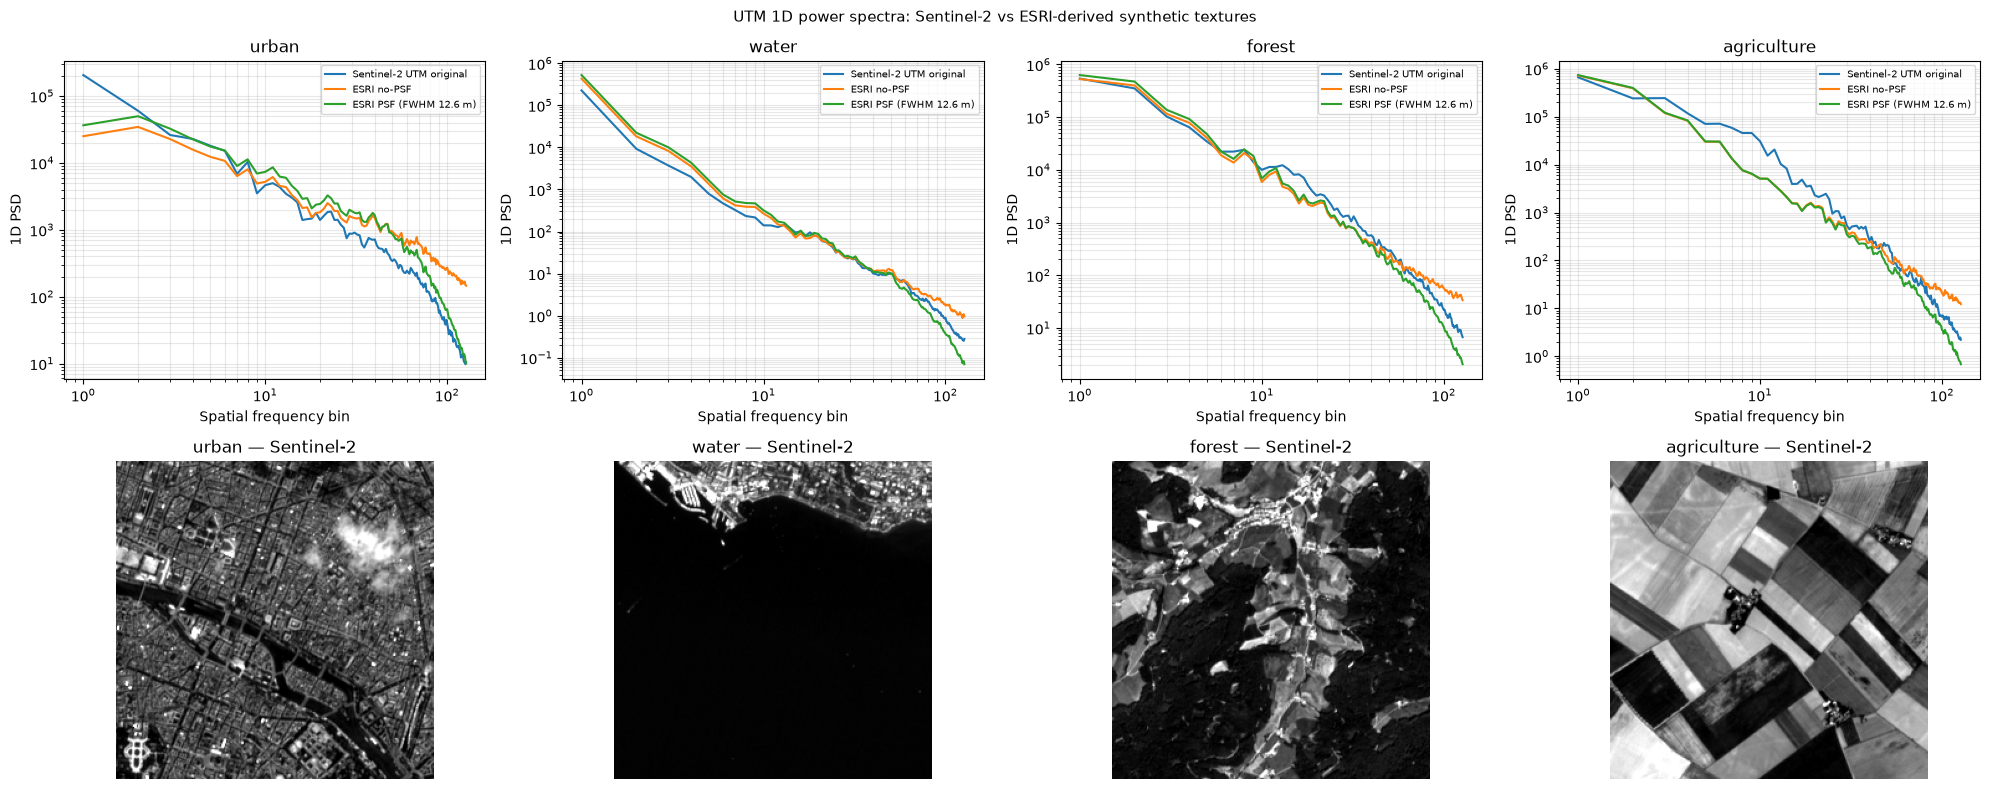

In [56]:
def plot_utm_psd_sentinel2_esri(force=False):
    scenes = list(benchmark_coordinates.keys())
    fig, axes = plt.subplots(2, len(scenes), figsize=(5 * len(scenes), 8), sharey=False)

    for c, scene in enumerate(scenes):
        ax_top = axes[0, c]; ax_bot = axes[1, c]

        # Sentinel-2 real image
        s2_img, _, _, _ = load_scene_patch(scene)
        s2_img = central_crop(s2_img)

        prod = build_synthetic_detector_products(scene, fwhm_m=FWHM, force=force)
        k_s2,   p_s2   = psd1d_numpy(s2_img)
        k_noP,  p_noP  = psd1d_numpy(prod["utm_ref_no_psf"])
        k_psf,  p_psf  = psd1d_numpy(prod["utm_det_psf"])

        ax_top.loglog(k_s2,  p_s2,  label="Sentinel-2 UTM original")
        ax_top.loglog(k_noP, p_noP, label="ESRI no-PSF")
        ax_top.loglog(k_psf, p_psf, label=f"ESRI PSF (FWHM {FWHM} m)")
        ax_top.set_title(scene); ax_top.legend(fontsize=7)
        ax_top.set_xlabel("Spatial frequency bin"); ax_top.set_ylabel("1D PSD")
        ax_top.grid(True, which="both", alpha=0.3)

        # Image display
        ax_bot.imshow(s2_img, cmap="gray",
                      vmin=np.nanpercentile(s2_img, 1),
                      vmax=np.nanpercentile(s2_img, 99))
        ax_bot.set_title(f"{scene} — Sentinel-2"); ax_bot.axis("off")

    fig.suptitle("UTM 1D power spectra: Sentinel-2 vs ESRI-derived synthetic textures", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig4_utm_psd_s2_esri.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "fig4_utm_psd_s2_esri.png", dpi=200, bbox_inches="tight")
    return fig

fig_utm_psd = plot_utm_psd_sentinel2_esri()
plt.show()


## 15. Runtime comparison

In [57]:
def collect_runtime_table(force=False):
    rows = []
    for scene in benchmark_coordinates:
        # PSF-aware
        try:
            t0 = time.time()
            psf = psf_resample_scene(scene, force=True)
            t_psf = time.time() - t0
            rows.append({"scene": scene, "method": "psf_aware",
                         "total_s": t_psf,
                         "build_s": float(psf.get("build_time", np.nan)),
                         "invert_s": float(psf.get("inversion_time", np.nan)),
                         "project_s": float(psf.get("projection_time", np.nan))})
        except Exception as exc:
            print(f"[WARN] runtime PSF-aware {scene}: {exc}")

        # Classical
        for method in CLASSICAL_METHODS:
            try:
                t0 = time.time()
                classical_resample_scene(scene, method=method, force=True )
                t_cl = time.time() - t0
                rows.append({"scene": scene, "method": f"classical_{method}",
                             "total_s": t_cl,
                             "build_s": np.nan, "invert_s": np.nan, "project_s": np.nan})
            except Exception as exc:
                print(f"[WARN] runtime classical {method} {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "runtime_table.csv", index=False)
    return df

df_runtime = collect_runtime_table(force=False)
df_runtime


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.08172
Itt 4 : 2.591e-07
Itt 8 : 8.503e-13
Itt 12 : 5.294e-13
Final Itt 13 : 1.291e-11
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.0106
Itt 4 : 2.852e-08
Itt 8 : 8.038e-14
Itt 12 : 1.089e-13
Final Itt 13 : 2.658e-12
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.00585
Itt 4 : 1.817e-08
Itt 8 : 5.533e-14
Itt 12 : 3.952e-14
Final Itt 13 : 9.756e-13
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.004916
Itt 4 : 1.556e-08
Itt 8 : 4.955e-14
Itt 12 : 2.765e-14
Final Itt 13 : 6.693e-13


,scene,method,total_s,build_s,invert_s,project_s
0,urban,psf_aware,1.320483,0.558901,0.548383,0.013948
1,urban,classical_nearest,0.229755,NaN,NaN,NaN
2,urban,classical_linear,0.818836,NaN,NaN,NaN
3,urban,classical_cubic,1.777032,NaN,NaN,NaN
4,water,psf_aware,1.307939,0.527136,0.553725,0.014414
5,water,classical_nearest,0.240525,NaN,NaN,NaN
6,water,classical_linear,0.831271,NaN,NaN,NaN
7,water,classical_cubic,1.805597,NaN,NaN,NaN
8,forest,psf_aware,1.566277,0.534239,0.803811,0.030665
9,forest,classical_nearest,0.235913,NaN,NaN,NaN


## 16. Summary

This notebook produced the following outputs in `figures/` and `tables/`:

| File | Content |
|------|---------|
| `table_I_synthetic.csv` / `.tex` | Synthetic detector metrics — all methods (paper Table I) |
| `table_II_roundtrip.csv` / `.tex` | Round-trip metrics — all methods (paper Table II) |
| `roundtrip_metrics_all_methods.csv` | Full long-format round-trip metrics |
| `synthetic_metrics_all_methods.csv` | Full long-format synthetic metrics |
| `runtime_table.csv` | Runtime measurements per method and scene |
| `fig2_synthetic_comparison_all_methods.pdf/png` | Figure 2 with all methods |
| `roundtrip_residuals_all_methods.pdf/png` | Round-trip residual maps |
| `roundtrip_psd_all_methods.pdf/png` | Round-trip 1D PSD comparison |
| `synthetic_psd_all_methods.pdf/png` | Synthetic detector PSD comparison |
| `fig4_utm_psd_s2_esri.pdf/png` | Figure 4 — UTM PSD Sentinel-2 vs ESRI |

### Key interpretation notes

- **PSF-aware RMSE** in Table II should be orders of magnitude lower than classical baselines (e.g. ≈ 10⁻⁵ vs. 10⁻² for bilinear), confirming that the proposed method better preserves round-trip fidelity.
- In Table I (synthetic), classical methods are expected to be closer to `esri_psf` (they do not deconvolve the PSF); PSF-aware should sit between the PSF and no-PSF references.
- The spectral plots quantify where each method attenuates or amplifies spatial frequencies relative to the original.
